# EDA

## Mount to Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# path
TRUE_PATH = '/content/drive/MyDrive/datasets/deepLearning/FP/True.csv'
FAKE_PATH = '/content/drive/MyDrive/datasets/deepLearning/FP/Fake.csv'
SAVE_PATH = '/content/drive/MyDrive/datasets/deepLearning/FP/isot_merged.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load and Label Dataset

In [2]:
import pandas as pd

df_true = pd.read_csv(TRUE_PATH)
df_fake = pd.read_csv(FAKE_PATH)

df_true['label'] = 0  # Real
df_fake['label'] = 1  # Fake

df = pd.concat([df_true, df_fake], ignore_index=True)

print(f'Total samples : {len(df):,}')
print(f'Real news     : {len(df_true):,}')
print(f'Fake news     : {len(df_fake):,}')
print(f'Columns       : {df.columns.tolist()}')

Total samples : 44,898
Real news     : 21,417
Fake news     : 23,481
Columns       : ['title', 'text', 'subject', 'date', 'label']


## Basic Info & Missing Values

In [3]:
print('=== Shape ===')
print(df.shape)

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Sample Rows ===')
print(df.head(3).to_string())

=== Shape ===
(44898, 5)

=== Data Types ===
title      object
text       object
subject    object
date       object
label       int64
dtype: object

=== Missing Values ===
title      0
text       0
subject    0
date       0
label      0
dtype: int64

=== Sample Rows ===
                                                              title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

## Class Distirbution Plots

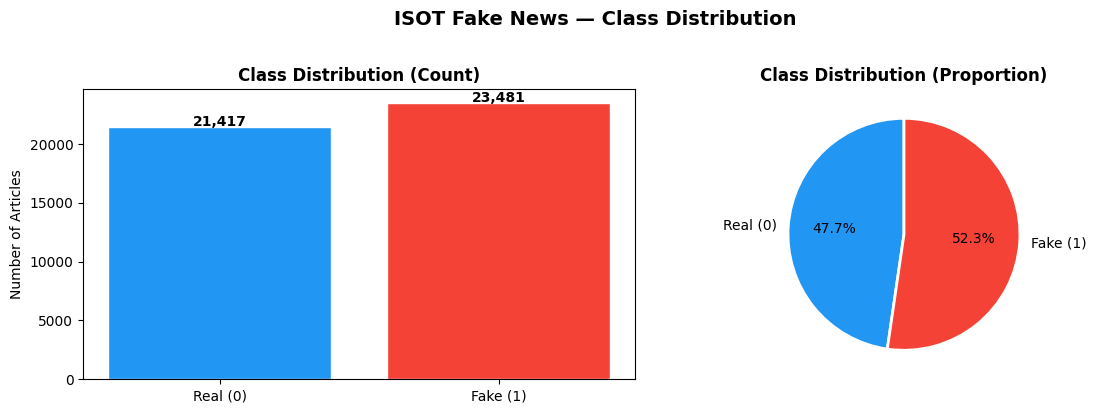

Balance ratio: 0.912  (1.0 = perfect balance)


In [4]:
import matplotlib.pyplot as plt

label_counts = df['label'].value_counts().sort_index()
label_names  = ['Real (0)', 'Fake (1)']
colors       = ['#2196F3', '#F44336']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(label_names, label_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Class Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Number of Articles')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(
    label_counts.values,
    labels=label_names,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Class Distribution (Proportion)', fontweight='bold')

plt.suptitle('ISOT Fake News — Class Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Balance ratio: {label_counts[0] / label_counts[1]:.3f}  (1.0 = perfect balance)')

## Text Length Analysis

In [5]:
df['title_len'] = df['title'].fillna('').apply(lambda x: len(x.split()))
df['text_len']  = df['text'].fillna('').apply(lambda x: len(x.split()))

print('=== Title Length (words) ===')
print(df['title_len'].describe().round(1))

print('\n=== Body Length (words) ===')
print(df['text_len'].describe().round(1))

p95_title = int(df['title_len'].quantile(0.95))
p95_text  = int(df['text_len'].quantile(0.95))
print(f'\n95th percentile — title : {p95_title} words')
print(f'95th percentile — body  : {p95_text} words')
# Use p95_text to justify your max_length choice in preprocessing

=== Title Length (words) ===
count    44898.0
mean        12.5
std          4.1
min          1.0
25%         10.0
50%         11.0
75%         14.0
max         42.0
Name: title_len, dtype: float64

=== Body Length (words) ===
count    44898.0
mean       405.3
std        351.3
min          0.0
25%        203.0
50%        362.0
75%        513.0
max       8135.0
Name: text_len, dtype: float64

95th percentile — title : 20 words
95th percentile — body  : 904 words


## Length Distribution Plot

In [6]:
df['title_len'] = df['title'].fillna('').apply(lambda x: len(x.split()))
df['text_len']  = df['text'].fillna('').apply(lambda x: len(x.split()))

print('=== Title Length (words) ===')
print(df['title_len'].describe().round(1))

print('\n=== Body Length (words) ===')
print(df['text_len'].describe().round(1))

p95_title = int(df['title_len'].quantile(0.95))
p95_text  = int(df['text_len'].quantile(0.95))
print(f'\n95th percentile — title : {p95_title} words')
print(f'95th percentile — body  : {p95_text} words')
# Use p95_text to justify your max_length choice in preprocessing

=== Title Length (words) ===
count    44898.0
mean        12.5
std          4.1
min          1.0
25%         10.0
50%         11.0
75%         14.0
max         42.0
Name: title_len, dtype: float64

=== Body Length (words) ===
count    44898.0
mean       405.3
std        351.3
min          0.0
25%        203.0
50%        362.0
75%        513.0
max       8135.0
Name: text_len, dtype: float64

95th percentile — title : 20 words
95th percentile — body  : 904 words


## Subject Distribution

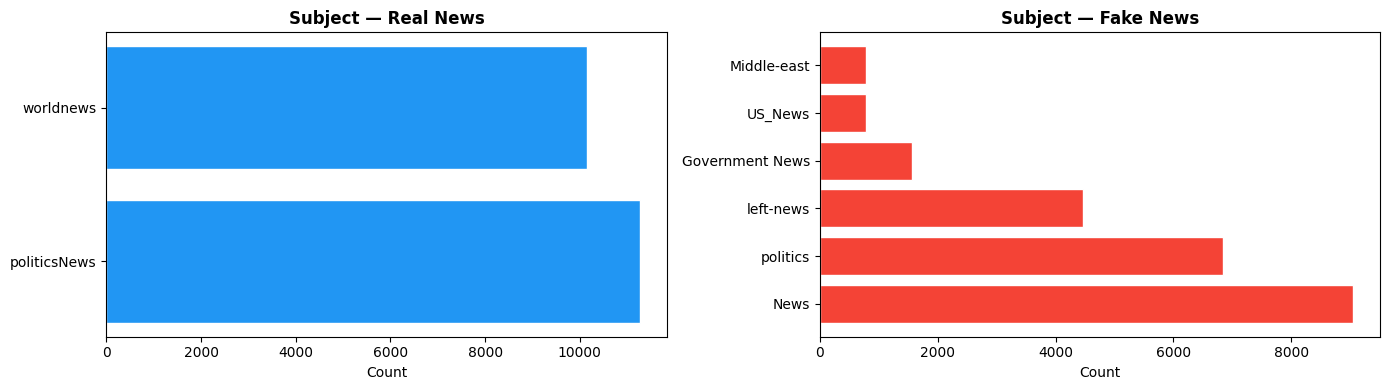

In [7]:
import matplotlib.pyplot as plt

if 'subject' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, label_val, label_name, color in zip(
        axes, [0, 1], ['Real News', 'Fake News'], ['#2196F3', '#F44336']
    ):
        counts = df[df['label'] == label_val]['subject'].value_counts()
        ax.barh(counts.index, counts.values, color=color, edgecolor='white')
        ax.set_title(f'Subject — {label_name}', fontweight='bold')
        ax.set_xlabel('Count')
    plt.tight_layout()
    plt.savefig('subject_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No subject column found.')

## Word Cloud: Real NewsM

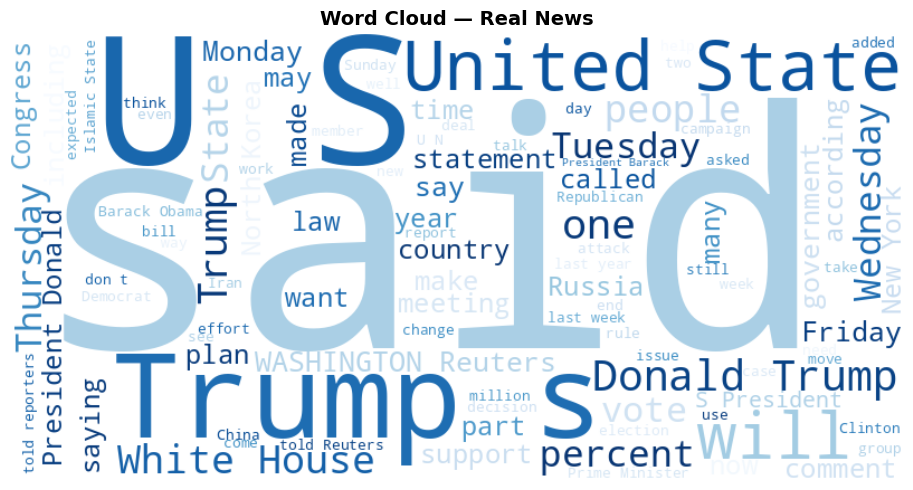

In [8]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

real_text = ' '.join(df[df['label'] == 0]['text'].fillna('').values)

wc_real = WordCloud(width=800, height=400, background_color='white',
                    colormap='Blues', max_words=100).generate(real_text)

plt.figure(figsize=(12, 5))
plt.imshow(wc_real, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Real News', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud_real.png', dpi=150, bbox_inches='tight')
plt.show()

## Word Cloud: Fake News

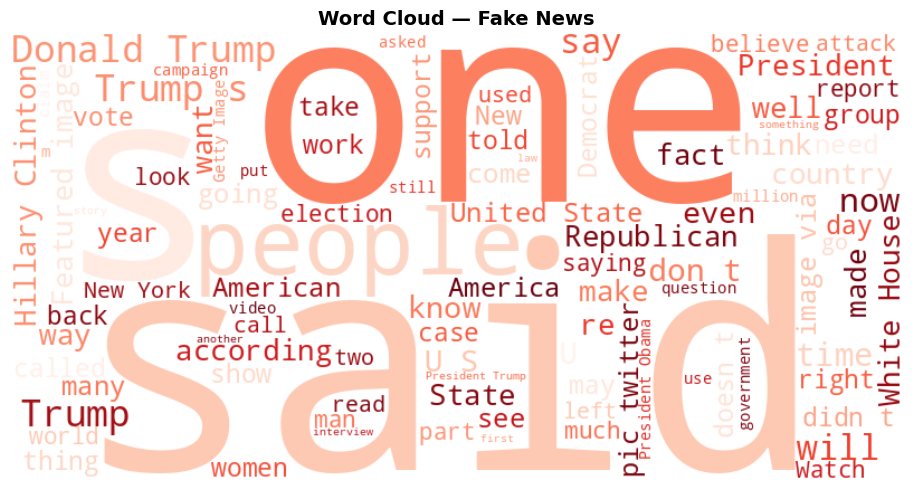

In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fake_text = ' '.join(df[df['label'] == 1]['text'].fillna('').values)

wc_fake = WordCloud(width=800, height=400, background_color='white',
                    colormap='Reds', max_words=100).generate(fake_text)

plt.figure(figsize=(12, 5))
plt.imshow(wc_fake, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Fake News', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud_fake.png', dpi=150, bbox_inches='tight')
plt.show()

## Top 15 Words per Class

In [10]:
from collections import Counter

STOPWORDS = {
    'the','a','an','is','it','in','on','at','to','and','or','of',
    'for','with','that','this','was','are','be','as','by','from',
    'he','she','his','her','they','their','we','our','have','has',
    'had','not','but','so','if','about','said','will','would','its'
}

def top_words(texts, n=15):
    words = ' '.join(texts.fillna('')).lower().split()
    words = [w for w in words if w.isalpha() and w not in STOPWORDS]
    return Counter(words).most_common(n)

print('Top 15 words — REAL:')
for word, count in top_words(df[df['label'] == 0]['text']):
    print(f'  {word:<20} {count:,}')

print('\nTop 15 words — FAKE:')
for word, count in top_words(df[df['label'] == 1]['text']):
    print(f'  {word:<20} {count:,}')

Top 15 words — REAL:
  s                    44,709
  trump                36,485
  who                  27,388
  president            23,399
  which                20,707
  been                 19,541
  after                19,241
  were                 18,811
  more                 16,747
  new                  16,578
  also                 15,870
  state                15,608
  united               15,521
  government           15,319
  house                14,550

Top 15 words — FAKE:
  s                    128,331
  trump                65,511
  i                    42,571
  who                  41,633
  t                    39,686
  you                  37,167
  what                 23,849
  been                 22,811
  people               22,359
  all                  22,098
  president            22,080
  one                  21,561
  were                 21,368
  when                 20,982
  out                  20,489


## Summary Table

In [11]:
import pandas as pd

summary_df = pd.DataFrame({
    'Attribute' : ['Source', 'Total Samples', 'Real Articles', 'Fake Articles',
                   'Avg Title Length', 'Avg Body Length', 'Label Type', 'Columns'],
    'Value'     : [
        'ISOT Fake News Dataset (University of Victoria)',
        f'{len(df):,}',
        f'{len(df_true):,}',
        f'{len(df_fake):,}',
        f"{df['title_len'].mean():.1f} words",
        f"{df['text_len'].mean():.1f} words",
        'Binary (0 = Real, 1 = Fake)',
        str(df.columns.drop('label').tolist())
    ]
})
print(summary_df.to_string(index=False))

       Attribute                                                         Value
          Source               ISOT Fake News Dataset (University of Victoria)
   Total Samples                                                        44,898
   Real Articles                                                        21,417
   Fake Articles                                                        23,481
Avg Title Length                                                    12.5 words
 Avg Body Length                                                   405.3 words
      Label Type                                   Binary (0 = Real, 1 = Fake)
         Columns ['title', 'text', 'subject', 'date', 'title_len', 'text_len']


## Save & Merged dataset

In [12]:
df.to_csv(SAVE_PATH, index=False)
print(f'Saved to : {SAVE_PATH}')
print(f'Shape    : {df.shape}')
print('\nEDA Done')

Saved to : /content/drive/MyDrive/datasets/deepLearning/FP/isot_merged.csv
Shape    : (44898, 7)

EDA Done


# Preprocessing

## Import & Configs

In [13]:
import pandas as pd
import numpy as np
import re
import os

# Paths
MERGED_PATH = '/content/drive/MyDrive/datasets/deepLearning/FP/isot_merged.csv'
SAVE_DIR    = '/content/drive/MyDrive/datasets/deepLearning/FP/processed'

os.makedirs(SAVE_DIR, exist_ok=True)

# Global config
MAX_LENGTH  = 512   # justified by 95th percentile body length (904 words)
RANDOM_SEED = 42
TEST_SIZE   = 0.10
VAL_SIZE    = 0.10  # of total, so train=80 / val=10 / test=10

print('Config ready.')
print(f'  MAX_LENGTH  : {MAX_LENGTH}')
print(f'  RANDOM_SEED : {RANDOM_SEED}')
print(f'  Split       : 80% train / 10% val / 10% test')

Config ready.
  MAX_LENGTH  : 512
  RANDOM_SEED : 42
  Split       : 80% train / 10% val / 10% test


## Load & Merged dataset

In [14]:
import pandas as pd

df = pd.read_csv(MERGED_PATH)

print(f'Loaded : {df.shape}')
print(df.head(2).to_string())

Loaded : (44898, 7)
                                                              title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

## Drop unused columns

In [15]:
# Drop 'date'  → not a text feature, would cause leakage
# Drop 'subject' → categorical bias, not used as model input
COLUMNS_TO_DROP = ['date', 'subject']

df = df.drop(columns=COLUMNS_TO_DROP)

print(f'Remaining columns : {df.columns.tolist()}')
print(f'Shape             : {df.shape}')

Remaining columns : ['title', 'text', 'label', 'title_len', 'text_len']
Shape             : (44898, 5)


## Expand Contractions

In [16]:
# Justified by EDA: 's' and 't' noise tokens are contraction artifacts
# e.g. "don't" → "do not", "it's" → "it is"

CONTRACTIONS = {
    "n't": " not", "'re": " are", "'s": " is", "'d": " would",
    "'ll": " will", "'ve": " have", "'m": " am", "won't": "will not",
    "can't": "cannot", "i'm": "i am", "you're": "you are",
    "it's": "it is", "that's": "that is", "he's": "he is",
    "she's": "she is", "we're": "we are", "they're": "they are",
    "i've": "i have", "you've": "you have", "we've": "we have",
    "i'd": "i would", "you'd": "you would", "he'd": "he would",
    "she'd": "she would", "we'd": "we would", "they'd": "they would",
    "i'll": "i will", "you'll": "you will", "he'll": "he will",
    "she'll": "she will", "we'll": "we will", "they'll": "they will",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "weren't": "were not", "hasn't": "has not", "haven't": "have not",
    "hadn't": "had not", "doesn't": "does not", "don't": "do not",
    "didn't": "did not", "couldn't": "could not", "shouldn't": "should not",
    "wouldn't": "would not", "mightn't": "might not", "mustn't": "must not"
}

def expand_contractions(text):
    text = text.lower()
    for contraction, expansion in CONTRACTIONS.items():
        text = text.replace(contraction, expansion)
    return text

# Quick test
sample = "He doesn't know what they're doing, it's wrong"
print('Before:', sample)
print('After :', expand_contractions(sample))

Before: He doesn't know what they're doing, it's wrong
After : he does not know what they are doing, it is wrong


## Text Cleaning Function

In [17]:
import re

def clean_text(text):
    text = str(text).lower()                           # lowercase FIRST
    text = re.sub(r"'s\b", " is", text)               # it's → it is (catch possessives too)
    text = re.sub(r"n't\b", " not", text)              # don't → do not
    text = re.sub(r"'re\b", " are", text)              # they're → they are
    text = re.sub(r"'ve\b", " have", text)             # i've → i have
    text = re.sub(r"'ll\b", " will", text)             # i'll → i will
    text = re.sub(r"'d\b",  " would", text)            # i'd → i would
    text = re.sub(r"'m\b",  " am", text)               # i'm → i am
    text = expand_contractions(text)                   # catch any remaining
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # remove URLs
    text = re.sub(r'<.*?>', '', text)                   # remove HTML tags
    text = re.sub(r'\(reuters\)', '', text)             # remove Reuters byline
    text = re.sub(r'[^a-z\s]', '', text)               # remove punctuation & numbers
    text = re.sub(r'\b\w\b', '', text)                 # remove single-char tokens (s, t, i)
    text = re.sub(r'\s+', ' ', text).strip()           # collapse whitespace
    return text

# Test
sample = "WASHINGTON (Reuters) - The U.S. gov't said it's not true! Visit https://example.com"
print('Before:', sample)
print('After :', clean_text(sample))

Before: WASHINGTON (Reuters) - The U.S. gov't said it's not true! Visit https://example.com
After : washington the us govt said it is not true visit


## Combine Title + Body, Apply Cleaning

In [18]:
# Combine title and text — EDA showed both carry signal
# Separator token [SEP] helps BERT distinguish title from body
# For LSTM/CNN we just concatenate with a space

df['combined_raw']    = df['title'].fillna('') + ' [SEP] ' + df['text'].fillna('')
df['combined_clean']  = df['combined_raw'].apply(clean_text)

print('Sample combined_clean:')
print(df['combined_clean'].iloc[0][:300])
print(f'\nTotal rows : {len(df)}')

Sample combined_clean:
as us budget fight looms republicans flip their fiscal script sep washington the head of conservative republican faction in the us congress who voted this month for huge expansion of the national debt to pay for tax cuts called himself fiscal conservative on sunday and urged budget restraint in in k

Total rows : 44898


## Verify Cleaning Quality

In [19]:
# Check that noisy tokens ('s', 't') are gone after cleaning
from collections import Counter

def top_words(texts, n=15):
    words = ' '.join(texts).split()
    return Counter(words).most_common(n)

print('Top 15 tokens AFTER cleaning — Real:')
for word, count in top_words(df[df['label'] == 0]['combined_clean'], n=15):
    print(f'  {word:<20} {count:,}')

print('\nTop 15 tokens AFTER cleaning — Fake:')
for word, count in top_words(df[df['label'] == 1]['combined_clean'], n=15):
    print(f'  {word:<20} {count:,}')

Top 15 tokens AFTER cleaning — Real:
  the                  482,721
  to                   252,970
  of                   207,977
  in                   185,290
  and                  182,269
  on                   111,720
  said                 99,053
  that                 87,197
  for                  82,516
  is                   60,332
  with                 56,001
  he                   53,660
  as                   48,403
  by                   48,229
  was                  48,063

Top 15 tokens AFTER cleaning — Fake:
  the                  534,183
  to                   299,162
  of                   240,969
  and                  228,231
  in                   169,268
  that                 151,130
  is                   115,536
  for                  96,826
  on                   84,909
  trump                81,327
  it                   80,041
  he                   78,717
  was                  68,613
  with                 65,382
  his                  59,663


## Train / Val / Test Split

In [20]:
from sklearn.model_selection import train_test_split

X = df['combined_clean'].values
y = df['label'].values

# First split off test (10%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_SEED
)

# Then split remaining into train (80%) and val (10%)
val_ratio = VAL_SIZE / (1 - TEST_SIZE)  # = 0.10 / 0.90 ≈ 0.111
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_ratio,
    stratify=y_temp,
    random_state=RANDOM_SEED
)

print(f'Train : {len(X_train):,}  ({len(X_train)/len(X)*100:.1f}%)')
print(f'Val   : {len(X_val):,}   ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test  : {len(X_test):,}   ({len(X_test)/len(X)*100:.1f}%)')

# Verify stratification
for split_name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    fake_pct = y_split.sum() / len(y_split) * 100
    print(f'{split_name} fake% : {fake_pct:.1f}%')

Train : 35,918  (80.0%)
Val   : 4,490   (10.0%)
Test  : 4,490   (10.0%)
Train fake% : 52.3%
Val fake% : 52.3%
Test fake% : 52.3%


## Save Splits (shared by all models)

In [21]:
import pandas as pd

train_df = pd.DataFrame({'text': X_train, 'label': y_train})
val_df   = pd.DataFrame({'text': X_val,   'label': y_val})
test_df  = pd.DataFrame({'text': X_test,  'label': y_test})

train_df.to_csv(f'{SAVE_DIR}/train.csv', index=False)
val_df.to_csv(f'{SAVE_DIR}/val.csv',     index=False)
test_df.to_csv(f'{SAVE_DIR}/test.csv',   index=False)

print(f'Saved to: {SAVE_DIR}')
print(f'  train.csv : {len(train_df):,} rows')
print(f'  val.csv   : {len(val_df):,} rows')
print(f'  test.csv  : {len(test_df):,} rows')
print('\nPreprocessing done!')

Saved to: /content/drive/MyDrive/datasets/deepLearning/FP/processed
  train.csv : 35,918 rows
  val.csv   : 4,490 rows
  test.csv  : 4,490 rows

Preprocessing done!


# LSTM

## Install & Verify

In [22]:
# Check TensorFlow version (Colab usually has it pre-installed)
import tensorflow as tf
print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {tf.config.list_physical_devices("GPU")}')

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Config

In [23]:
PROCESSED_DIR = '/content/drive/MyDrive/datasets/deepLearning/FP/processed'
SAVE_DIR      = '/content/drive/MyDrive/datasets/deepLearning/FP/models'

import os
os.makedirs(SAVE_DIR, exist_ok=True)

MAX_VOCAB    = 20000   # top N words to keep in vocabulary
MAX_LENGTH   = 512     # max tokens per input (justified by EDA 95th percentile)
EMBED_DIM    = 100     # GloVe 100d
LSTM_UNITS   = 128
DROPOUT      = 0.3
BATCH_SIZE   = 64
EPOCHS       = 10
RANDOM_SEED  = 42

import numpy as np
import tensorflow as tf
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print('Config ready.')

Config ready.


## Load Split

In [24]:
import pandas as pd

train_df = pd.read_csv(f'{PROCESSED_DIR}/train.csv')
val_df   = pd.read_csv(f'{PROCESSED_DIR}/val.csv')
test_df  = pd.read_csv(f'{PROCESSED_DIR}/test.csv')

X_train, y_train = train_df['text'].values, train_df['label'].values
X_val,   y_val   = val_df['text'].values,   val_df['label'].values
X_test,  y_test  = test_df['text'].values,  test_df['label'].values

print(f'Train : {len(X_train):,}')
print(f'Val   : {len(X_val):,}')
print(f'Test  : {len(X_test):,}')

Train : 35,918
Val   : 4,490
Test  : 4,490


## Build Vocabulary & Tokenize

In [25]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Fit tokenizer on training set ONLY — never on val/test
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert text to integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad to fixed length (post-padding, post-truncation)
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LENGTH, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LENGTH, padding='post', truncating='post')

vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)

print(f'Vocab size      : {vocab_size:,}')
print(f'Train shape     : {X_train_pad.shape}')
print(f'Val shape       : {X_val_pad.shape}')
print(f'Test shape      : {X_test_pad.shape}')

Vocab size      : 20,000
Train shape     : (35918, 512)
Val shape       : (4490, 512)
Test shape      : (4490, 512)


## Load GloVe Embeddings

In [26]:
import numpy as np

import os
GLOVE_PATH = '/content/drive/MyDrive/datasets/deepLearning/FP/glove.6B.100d.txt'

# Build embedding index
embeddings_index = {}
with open(GLOVE_PATH, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word   = values[0]
        vector = np.array(values[1:], dtype='float32')
        embeddings_index[word] = vector

print(f'GloVe vectors loaded : {len(embeddings_index):,}')

# Build embedding matrix aligned to our tokenizer vocabulary
embedding_matrix = np.zeros((vocab_size, EMBED_DIM))
hits, misses = 0, 0

for word, idx in tokenizer.word_index.items():
    if idx >= MAX_VOCAB:
        continue
    vector = embeddings_index.get(word)
    if vector is not None:
        embedding_matrix[idx] = vector
        hits += 1
    else:
        misses += 1

print(f'Vocab hits   : {hits:,}')
print(f'Vocab misses : {misses:,}')
print(f'Coverage     : {hits / (hits + misses) * 100:.1f}%')

GloVe vectors loaded : 400,000
Vocab hits   : 18,943
Vocab misses : 1,056
Coverage     : 94.7%


## Build LSTM Model

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model_lstm = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBED_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LENGTH,
        trainable=False          # freeze GloVe weights
    ),
    LSTM(LSTM_UNITS),
    Dropout(DROPOUT),
    Dense(1, activation='sigmoid')
], name='LSTM_Model')

model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

## Callbacks

In [28]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

LSTM_CKPT = f'{SAVE_DIR}/lstm_best.keras'

callbacks_lstm = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=LSTM_CKPT,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]

print('Callbacks ready.')

Callbacks ready.


## Train LSTM

In [29]:
import time

start_time = time.time()

history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_lstm,
    verbose=1
)

lstm_train_time = time.time() - start_time
print(f'\nTraining time : {lstm_train_time:.1f}s  ({lstm_train_time/60:.1f} min)')

Epoch 1/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6159 - loss: 0.6303
Epoch 1: val_loss improved from None to 0.42711, saving model to /content/drive/MyDrive/datasets/deepLearning/FP/models/lstm_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/datasets/deepLearning/FP/models/lstm_best.keras
562/562 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.6950 - loss: 0.5676 - val_accuracy: 0.8396 - val_loss: 0.4271 - learning_rate: 0.0010
Epoch 2/10
561/562 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7642 - loss: 0.5021
Epoch 2: val_loss did not improve from 0.42711
562/562 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.6486 - loss: 0.5977 - val_accuracy: 0.5506 - val_loss: 0.6881 - learning_rate: 0.0010
Epoch 3/10
561/562 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5363 - loss: 0.6888
Epoch 3: val_loss did not improve from 0.42711

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
562/562 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/st

## Plot Training Curves

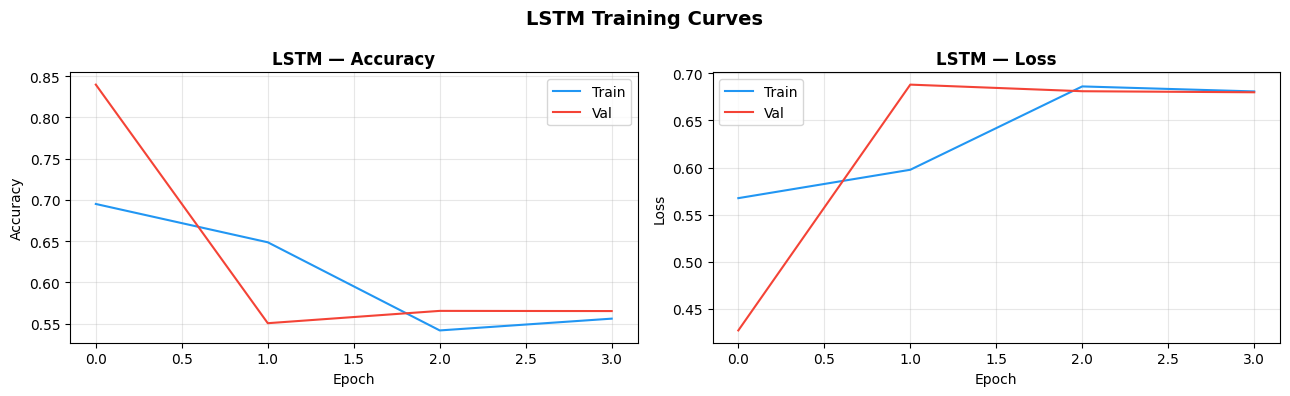

In [30]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Accuracy
axes[0].plot(history_lstm.history['accuracy'],     label='Train', color='#2196F3')
axes[0].plot(history_lstm.history['val_accuracy'], label='Val',   color='#F44336')
axes[0].set_title('LSTM — Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history_lstm.history['loss'],     label='Train', color='#2196F3')
axes[1].plot(history_lstm.history['val_loss'], label='Val',   color='#F44336')
axes[1].set_title('LSTM — Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('LSTM Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluate on Test Set

In [31]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import numpy as np

# Predict
y_pred_prob_lstm = model_lstm.predict(X_test_pad, verbose=0).flatten()
y_pred_lstm      = (y_pred_prob_lstm >= 0.5).astype(int)

# Metrics
results_lstm = {
    'Model'     : 'LSTM',
    'Accuracy'  : accuracy_score(y_test, y_pred_lstm),
    'Precision' : precision_score(y_test, y_pred_lstm),
    'Recall'    : recall_score(y_test, y_pred_lstm),
    'F1'        : f1_score(y_test, y_pred_lstm),
    'AUC-ROC'   : roc_auc_score(y_test, y_pred_prob_lstm),
    'Train Time': f'{lstm_train_time:.1f}s'
}

print('=== LSTM Test Results ===')
for k, v in results_lstm.items():
    if isinstance(v, float):
        print(f'  {k:<12} : {v:.4f}')
    else:
        print(f'  {k:<12} : {v}')

print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred_lstm, target_names=['Real', 'Fake']))

=== LSTM Test Results ===
  Model        : LSTM
  Accuracy     : 0.8432
  Precision    : 0.8125
  Recall       : 0.9101
  F1           : 0.8586
  AUC-ROC      : 0.8771
  Train Time   : 71.1s

=== Classification Report ===
              precision    recall  f1-score   support

        Real       0.89      0.77      0.82      2142
        Fake       0.81      0.91      0.86      2348

    accuracy                           0.84      4490
   macro avg       0.85      0.84      0.84      4490
weighted avg       0.85      0.84      0.84      4490



## Confusion Matrix

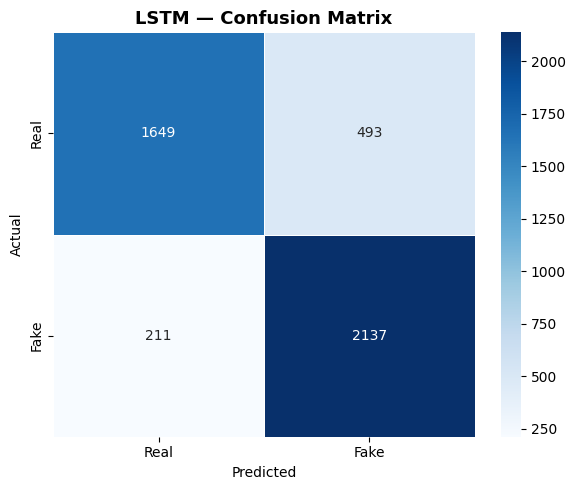

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Real', 'Fake'],
    yticklabels=['Real', 'Fake'],
    linewidths=0.5
)
plt.title('LSTM — Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('lstm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Save Results

In [33]:
import pickle

# Save tokenizer — reused by BiLSTM and TextCNN (same vocabulary)
with open(f'{SAVE_DIR}/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# Save results dict — we'll merge all model results in the final comparison notebook
with open(f'{SAVE_DIR}/results_lstm.pkl', 'wb') as f:
    pickle.dump(results_lstm, f)

print('Saved:')
print(f'  tokenizer.pkl')
print(f'  results_lstm.pkl')
print(f'\nLSTM done!')

Saved:
  tokenizer.pkl
  results_lstm.pkl

LSTM done!


# BiLSTM

## Config

In [34]:
import os
import numpy as np
import tensorflow as tf

PROCESSED_DIR = '/content/drive/MyDrive/datasets/deepLearning/FP/processed'
SAVE_DIR      = '/content/drive/MyDrive/datasets/deepLearning/FP/models'

MAX_VOCAB   = 20000
MAX_LENGTH  = 512
EMBED_DIM   = 100
LSTM_UNITS  = 128
DROPOUT     = 0.3
BATCH_SIZE  = 64
EPOCHS      = 10
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print('Config ready.')

Config ready.


##  Load Splits

In [35]:
import pandas as pd

train_df = pd.read_csv(f'{PROCESSED_DIR}/train.csv')
val_df   = pd.read_csv(f'{PROCESSED_DIR}/val.csv')
test_df  = pd.read_csv(f'{PROCESSED_DIR}/test.csv')

X_train, y_train = train_df['text'].values, train_df['label'].values
X_val,   y_val   = val_df['text'].values,   val_df['label'].values
X_test,  y_test  = test_df['text'].values,  test_df['label'].values

print(f'Train : {len(X_train):,}')
print(f'Val   : {len(X_val):,}')
print(f'Test  : {len(X_test):,}')

Train : 35,918
Val   : 4,490
Test  : 4,490


## Load Tokenizer (reuse from LSTM)

In [36]:
import pickle
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Reuse the same tokenizer fitted in 03_lstm.py
with open(f'{SAVE_DIR}/tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LENGTH, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LENGTH, padding='post', truncating='post')

vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)

print(f'Vocab size  : {vocab_size:,}')
print(f'Train shape : {X_train_pad.shape}')

Vocab size  : 20,000
Train shape : (35918, 512)


##  Load GloVe & Build Embedding Matrix

In [37]:
import numpy as np

GLOVE_PATH = '/content/drive/MyDrive/datasets/deepLearning/FP/glove.6B.100d.txt'

# Load GloVe vectors
embeddings_index = {}
with open(GLOVE_PATH, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word   = values[0]
        vector = np.array(values[1:], dtype='float32')
        embeddings_index[word] = vector

print(f'GloVe vectors loaded : {len(embeddings_index):,}')

# Build embedding matrix
embedding_matrix = np.zeros((vocab_size, EMBED_DIM))
hits, misses = 0, 0

for word, idx in tokenizer.word_index.items():
    if idx >= MAX_VOCAB:
        continue
    vector = embeddings_index.get(word)
    if vector is not None:
        embedding_matrix[idx] = vector
        hits += 1
    else:
        misses += 1

print(f'Coverage : {hits / (hits + misses) * 100:.1f}%')

GloVe vectors loaded : 400,000
Coverage : 94.7%


## Build BiLSTM Model

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

# Only change vs LSTM: wrap LSTM with Bidirectional()
# This processes the sequence both left→right and right→left
# Output dimension doubles: 128 units × 2 directions = 256

model_bilstm = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBED_DIM,
        weights=[embedding_matrix],
        trainable=False
    ),
    Bidirectional(LSTM(LSTM_UNITS)),
    Dropout(DROPOUT),
    Dense(1, activation='sigmoid')
], name='BiLSTM_Model')

model_bilstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_bilstm.summary()

Model: "BiLSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

## Callbacks

In [39]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

BILSTM_CKPT = f'{SAVE_DIR}/bilstm_best.keras'

callbacks_bilstm = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=BILSTM_CKPT,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]

print('Callbacks ready.')

Callbacks ready.


## Train BiLSTM

In [40]:
import time

start_time = time.time()

history_bilstm = model_bilstm.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_bilstm,
    verbose=1
)

bilstm_train_time = time.time() - start_time
print(f'\nTraining time : {bilstm_train_time:.1f}s  ({bilstm_train_time/60:.1f} min)')

Epoch 1/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8668 - loss: 0.3084
Epoch 1: val_loss improved from None to 0.05420, saving model to /content/drive/MyDrive/datasets/deepLearning/FP/models/bilstm_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/datasets/deepLearning/FP/models/bilstm_best.keras
562/562 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.9323 - loss: 0.1689 - val_accuracy: 0.9800 - val_loss: 0.0542 - learning_rate: 0.0010
Epoch 2/10
561/562 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9808 - loss: 0.0528
Epoch 2: val_loss improved from 0.05420 to 0.04836, saving model to /content/drive/MyDrive/datasets/deepLearning/FP/models/bilstm_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/datasets/deepLearning/FP/models/bilstm_best.keras
562/562 ━━━━━━━━━━━━━━━━━━━━ 28s 50ms/step - accuracy: 0.9848 - loss: 0.0429 - val_accuracy: 0.9835 - val_loss: 0.0484 - learning_rate: 0.0010
Epoch 3/10
561/562 ━━━━━━━━━━━━━━━━━━━━ 0s 47

## Plot Training Curves

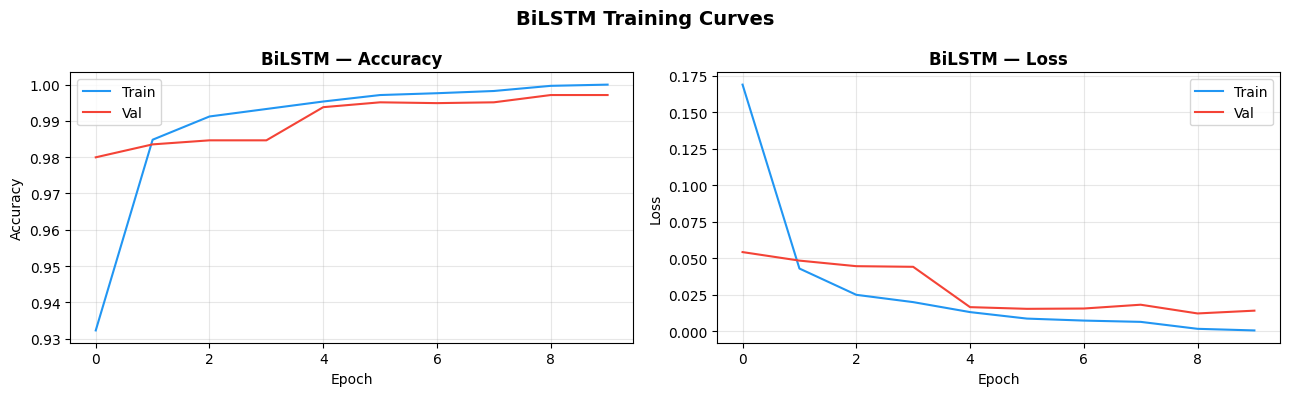

In [41]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_bilstm.history['accuracy'],     label='Train', color='#2196F3')
axes[0].plot(history_bilstm.history['val_accuracy'], label='Val',   color='#F44336')
axes[0].set_title('BiLSTM — Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_bilstm.history['loss'],     label='Train', color='#2196F3')
axes[1].plot(history_bilstm.history['val_loss'], label='Val',   color='#F44336')
axes[1].set_title('BiLSTM — Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('BiLSTM Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bilstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluate on Test Set

In [42]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

y_pred_prob_bilstm = model_bilstm.predict(X_test_pad, verbose=0).flatten()
y_pred_bilstm      = (y_pred_prob_bilstm >= 0.5).astype(int)

results_bilstm = {
    'Model'     : 'BiLSTM',
    'Accuracy'  : accuracy_score(y_test, y_pred_bilstm),
    'Precision' : precision_score(y_test, y_pred_bilstm),
    'Recall'    : recall_score(y_test, y_pred_bilstm),
    'F1'        : f1_score(y_test, y_pred_bilstm),
    'AUC-ROC'   : roc_auc_score(y_test, y_pred_prob_bilstm),
    'Train Time': f'{bilstm_train_time:.1f}s'
}

print('=== BiLSTM Test Results ===')
for k, v in results_bilstm.items():
    if isinstance(v, float):
        print(f'  {k:<12} : {v:.4f}')
    else:
        print(f'  {k:<12} : {v}')

print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred_bilstm, target_names=['Real', 'Fake']))

=== BiLSTM Test Results ===
  Model        : BiLSTM
  Accuracy     : 0.9962
  Precision    : 0.9957
  Recall       : 0.9970
  F1           : 0.9964
  AUC-ROC      : 0.9998
  Train Time   : 297.1s

=== Classification Report ===
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      2142
        Fake       1.00      1.00      1.00      2348

    accuracy                           1.00      4490
   macro avg       1.00      1.00      1.00      4490
weighted avg       1.00      1.00      1.00      4490



## Confusion Matrix

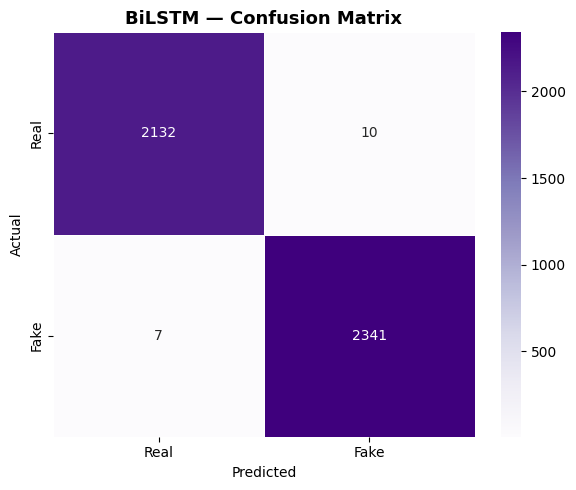

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_bilstm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Purples',
    xticklabels=['Real', 'Fake'],
    yticklabels=['Real', 'Fake'],
    linewidths=0.5
)
plt.title('BiLSTM — Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('bilstm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Compare LSTM vs BiLSTM So Far

In [44]:
import pandas as pd
import pickle

# Load LSTM results
with open(f'{SAVE_DIR}/results_lstm.pkl', 'rb') as f:
    results_lstm = pickle.load(f)

comparison_df = pd.DataFrame([results_lstm, results_bilstm])
comparison_df = comparison_df.set_index('Model')

print('=== LSTM vs BiLSTM ===')
print(comparison_df.to_string())

=== LSTM vs BiLSTM ===
        Accuracy  Precision    Recall        F1   AUC-ROC Train Time
Model                                                               
LSTM    0.843207   0.812548  0.910136  0.858578  0.877057      71.1s
BiLSTM  0.996214   0.995746  0.997019  0.996382  0.999808     297.1s


## Save BiLSTM Results

In [45]:
import pickle

with open(f'{SAVE_DIR}/results_bilstm.pkl', 'wb') as f:
    pickle.dump(results_bilstm, f)

print('Saved: results_bilstm.pkl')
print('\nBiLSTM done.')

Saved: results_bilstm.pkl

BiLSTM done.


## TextCNN

## Config

In [46]:
import os
import numpy as np
import tensorflow as tf

PROCESSED_DIR = '/content/drive/MyDrive/datasets/deepLearning/FP/processed'
SAVE_DIR      = '/content/drive/MyDrive/datasets/deepLearning/FP/models'

MAX_VOCAB    = 20000
MAX_LENGTH   = 512
EMBED_DIM    = 100
FILTER_SIZES = [2, 3, 4]   # kernel sizes — captures bigrams, trigrams, 4-grams
NUM_FILTERS  = 128          # filters per kernel size → 128 × 3 = 384 total features
DROPOUT      = 0.5          # higher dropout than LSTM — TextCNN overfits faster
BATCH_SIZE   = 64
EPOCHS       = 10
RANDOM_SEED  = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print('Config ready.')
print(f'  Filter sizes : {FILTER_SIZES}')
print(f'  Num filters  : {NUM_FILTERS} per size → {NUM_FILTERS * len(FILTER_SIZES)} total')

Config ready.
  Filter sizes : [2, 3, 4]
  Num filters  : 128 per size → 384 total


## Load Splits

In [47]:
import pandas as pd

train_df = pd.read_csv(f'{PROCESSED_DIR}/train.csv')
val_df   = pd.read_csv(f'{PROCESSED_DIR}/val.csv')
test_df  = pd.read_csv(f'{PROCESSED_DIR}/test.csv')

X_train, y_train = train_df['text'].values, train_df['label'].values
X_val,   y_val   = val_df['text'].values,   val_df['label'].values
X_test,  y_test  = test_df['text'].values,  test_df['label'].values

print(f'Train : {len(X_train):,}')
print(f'Val   : {len(X_val):,}')
print(f'Test  : {len(X_test):,}')

Train : 35,918
Val   : 4,490
Test  : 4,490


## Load Tokenizer & Pad Sequences

In [48]:
import pickle
from tensorflow.keras.preprocessing.sequence import pad_sequences

with open(f'{SAVE_DIR}/tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LENGTH, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LENGTH, padding='post', truncating='post')

vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)

print(f'Vocab size  : {vocab_size:,}')
print(f'Train shape : {X_train_pad.shape}')

Vocab size  : 20,000
Train shape : (35918, 512)


##  Load GloVe & Build Embedding Matrix

In [49]:
import numpy as np

GLOVE_PATH = '/content/drive/MyDrive/datasets/deepLearning/FP/glove.6B.100d.txt'

embeddings_index = {}
with open(GLOVE_PATH, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word   = values[0]
        vector = np.array(values[1:], dtype='float32')
        embeddings_index[word] = vector

print(f'GloVe vectors loaded : {len(embeddings_index):,}')

embedding_matrix = np.zeros((vocab_size, EMBED_DIM))
hits, misses = 0, 0

for word, idx in tokenizer.word_index.items():
    if idx >= MAX_VOCAB:
        continue
    vector = embeddings_index.get(word)
    if vector is not None:
        embedding_matrix[idx] = vector
        hits += 1
    else:
        misses += 1

print(f'Coverage : {hits / (hits + misses) * 100:.1f}%')

GloVe vectors loaded : 400,000
Coverage : 94.7%


## Build TextCNN Model

In [50]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Dense, Dropout, Concatenate
)

# TextCNN uses the Functional API — not Sequential
# because we need parallel branches for each filter size

input_layer = Input(shape=(MAX_LENGTH,), name='input')

# Shared embedding layer
embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=EMBED_DIM,
    weights=[embedding_matrix],
    trainable=False,
    name='embedding'
)(input_layer)

# Parallel convolutional branches — one per filter size
branches = []
for fs in FILTER_SIZES:
    conv = Conv1D(
        filters=NUM_FILTERS,
        kernel_size=fs,
        activation='relu',
        name=f'conv_{fs}gram'
    )(embedding_layer)
    pool = GlobalMaxPooling1D(name=f'pool_{fs}gram')(conv)
    branches.append(pool)

# Concatenate all branch outputs: 128 × 3 = 384 features
concat     = Concatenate(name='concat')(branches)
dropout    = Dropout(DROPOUT, name='dropout')(concat)
output     = Dense(1, activation='sigmoid', name='output')(dropout)

model_textcnn = Model(inputs=input_layer, outputs=output, name='TextCNN_Model')

model_textcnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_textcnn.summary()

Model: "TextCNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 512)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 512, 100)  │  2,000,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_2gram (Conv1D) │ (None, 511, 128)  │     25,728 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3gram (Conv1D) │ (None, 510, 128)  │     38,528 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_4gram (Conv1D) │ (None, 509, 128)  │     51,328 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_2gram          │ (None, 128)       │          0 │ conv_2gram[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_3gram          │ (None, 128)       │          0 │ conv_3gram[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_4gram          │ (None, 128)       │          0 │ conv_4gram[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 384)       │          0 │ pool_2gram[0][0], │
│ (Concatenate)       │                   │            │ pool_3gram[0][0], │
│                     │                   │            │ pool_4gram[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384)       │          0 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        385 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,115,969 (8.07 MB)

 Trainable params: 115,969 (453.00 KB)

 Non-trainable params: 2,000,000 (7.63 MB)

##Callbacks

In [51]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

TEXTCNN_CKPT = f'{SAVE_DIR}/textcnn_best.keras'

callbacks_textcnn = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=TEXTCNN_CKPT,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]

print('Callbacks ready.')

Callbacks ready.


## Train TextCNN

In [52]:
import time

start_time = time.time()

history_textcnn = model_textcnn.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_textcnn,
    verbose=1
)

textcnn_train_time = time.time() - start_time
print(f'\nTraining time : {textcnn_train_time:.1f}s  ({textcnn_train_time/60:.1f} min)')

Epoch 1/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8842 - loss: 0.2586
Epoch 1: val_loss improved from None to 0.02763, saving model to /content/drive/MyDrive/datasets/deepLearning/FP/models/textcnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/datasets/deepLearning/FP/models/textcnn_best.keras
562/562 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.9501 - loss: 0.1224 - val_accuracy: 0.9927 - val_loss: 0.0276 - learning_rate: 0.0010
Epoch 2/10
558/562 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9860 - loss: 0.0385
Epoch 2: val_loss improved from 0.02763 to 0.01854, saving model to /content/drive/MyDrive/datasets/deepLearning/FP/models/textcnn_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/datasets/deepLearning/FP/models/textcnn_best.keras
562/562 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9898 - loss: 0.0306 - val_accuracy: 0.9944 - val_loss: 0.0185 - learning_rate: 0.0010
Epoch 3/10
558/562 ━━━━━━━━━━━━━━━━━━━━ 0s

## Plot Training Curves

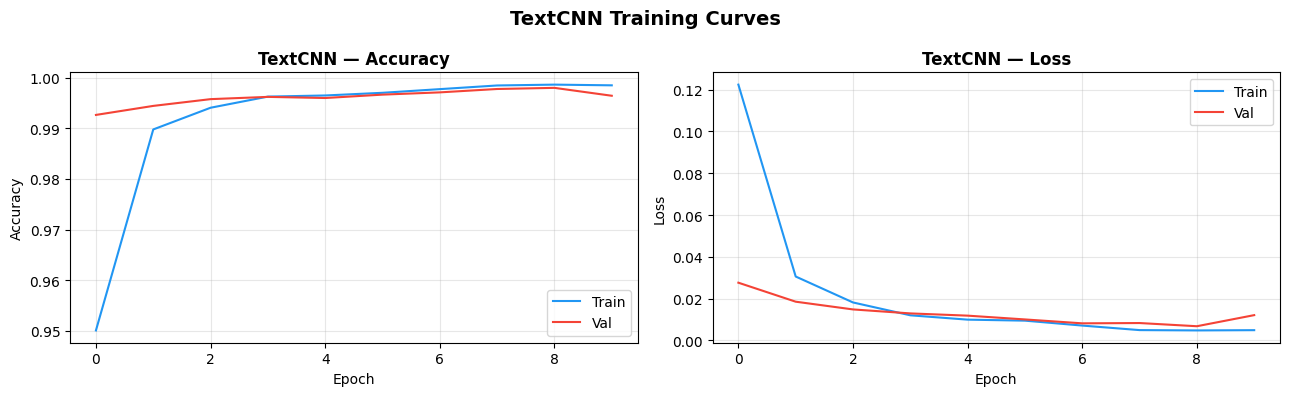

In [53]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_textcnn.history['accuracy'],     label='Train', color='#2196F3')
axes[0].plot(history_textcnn.history['val_accuracy'], label='Val',   color='#F44336')
axes[0].set_title('TextCNN — Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_textcnn.history['loss'],     label='Train', color='#2196F3')
axes[1].plot(history_textcnn.history['val_loss'], label='Val',   color='#F44336')
axes[1].set_title('TextCNN — Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('TextCNN Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('textcnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluate on Test Set

In [54]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

y_pred_prob_textcnn = model_textcnn.predict(X_test_pad, verbose=0).flatten()
y_pred_textcnn      = (y_pred_prob_textcnn >= 0.5).astype(int)

results_textcnn = {
    'Model'     : 'TextCNN',
    'Accuracy'  : accuracy_score(y_test, y_pred_textcnn),
    'Precision' : precision_score(y_test, y_pred_textcnn),
    'Recall'    : recall_score(y_test, y_pred_textcnn),
    'F1'        : f1_score(y_test, y_pred_textcnn),
    'AUC-ROC'   : roc_auc_score(y_test, y_pred_prob_textcnn),
    'Train Time': f'{textcnn_train_time:.1f}s'
}

print('=== TextCNN Test Results ===')
for k, v in results_textcnn.items():
    if isinstance(v, float):
        print(f'  {k:<12} : {v:.4f}')
    else:
        print(f'  {k:<12} : {v}')

print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred_textcnn, target_names=['Real', 'Fake']))

=== TextCNN Test Results ===
  Model        : TextCNN
  Accuracy     : 0.9982
  Precision    : 0.9979
  Recall       : 0.9987
  F1           : 0.9983
  AUC-ROC      : 1.0000
  Train Time   : 82.0s

=== Classification Report ===
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      2142
        Fake       1.00      1.00      1.00      2348

    accuracy                           1.00      4490
   macro avg       1.00      1.00      1.00      4490
weighted avg       1.00      1.00      1.00      4490



## Confusion Matrix

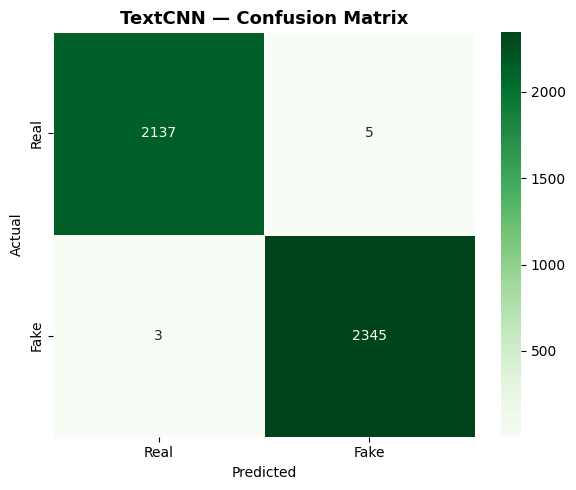

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_textcnn)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=['Real', 'Fake'],
    yticklabels=['Real', 'Fake'],
    linewidths=0.5
)
plt.title('TextCNN — Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('textcnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Three-Model Comparison So Far

In [56]:
import pandas as pd
import pickle

with open(f'{SAVE_DIR}/results_lstm.pkl', 'rb') as f:
    results_lstm = pickle.load(f)

with open(f'{SAVE_DIR}/results_bilstm.pkl', 'rb') as f:
    results_bilstm = pickle.load(f)

comparison_df = pd.DataFrame([results_lstm, results_bilstm, results_textcnn])
comparison_df = comparison_df.set_index('Model')

print('=== LSTM vs BiLSTM vs TextCNN ===')
print(comparison_df.to_string())

=== LSTM vs BiLSTM vs TextCNN ===
         Accuracy  Precision    Recall        F1   AUC-ROC Train Time
Model                                                                
LSTM     0.843207   0.812548  0.910136  0.858578  0.877057      71.1s
BiLSTM   0.996214   0.995746  0.997019  0.996382  0.999808     297.1s
TextCNN  0.998218   0.997872  0.998722  0.998297  0.999989      82.0s


## Save TextCNN Results

In [57]:
import pickle

with open(f'{SAVE_DIR}/results_textcnn.pkl', 'wb') as f:
    pickle.dump(results_textcnn, f)

print('Saved: results_textcnn.pkl')
print('\nTextCNN done.')

Saved: results_textcnn.pkl

TextCNN done.


# Distilbert

In [64]:
!pip install -q torch transformers datasets

## Config

In [65]:
import os
import numpy as np
import tensorflow as tf

PROCESSED_DIR = '/content/drive/MyDrive/datasets/deepLearning/FP/processed'
SAVE_DIR      = '/content/drive/MyDrive/datasets/deepLearning/FP/models'

MODEL_NAME  = 'distilbert-base-uncased'
MAX_LENGTH  = 512
BATCH_SIZE  = 16      # smaller than LSTM/CNN — transformer is memory heavy
EPOCHS      = 5       # transformers converge faster, 3-5 epochs is standard
LR          = 2e-5    # standard fine-tuning LR for BERT-family models
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

os.makedirs(SAVE_DIR, exist_ok=True)

print('Config ready.')
print(f'  Model      : {MODEL_NAME}')
print(f'  Max length : {MAX_LENGTH}')
print(f'  Batch size : {BATCH_SIZE}')
print(f'  LR         : {LR}')

Config ready.
  Model      : distilbert-base-uncased
  Max length : 512
  Batch size : 16
  LR         : 2e-05


## Load Splits

In [66]:
import pandas as pd

train_df = pd.read_csv(f'{PROCESSED_DIR}/train.csv')
val_df   = pd.read_csv(f'{PROCESSED_DIR}/val.csv')
test_df  = pd.read_csv(f'{PROCESSED_DIR}/test.csv')

X_train, y_train = train_df['text'].values, train_df['label'].values
X_val,   y_val   = val_df['text'].values,   val_df['label'].values
X_test,  y_test  = test_df['text'].values,  test_df['label'].values

print(f'Train : {len(X_train):,}')
print(f'Val   : {len(X_val):,}')
print(f'Test  : {len(X_test):,}')

Train : 35,918
Val   : 4,490
Test  : 4,490


## Load DistilBERT Tokenizer & Encode

In [67]:
from transformers import AutoTokenizer
import numpy as np

tokenizer_bert = AutoTokenizer.from_pretrained(MODEL_NAME)

def encode(texts, tokenizer, max_length):
    encoding = tokenizer(
        list(texts),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='np'
    )
    return encoding['input_ids'], encoding['attention_mask']

print('Encoding train set...')
X_train_ids, X_train_mask = encode(X_train, tokenizer_bert, MAX_LENGTH)

print('Encoding val set...')
X_val_ids,   X_val_mask   = encode(X_val,   tokenizer_bert, MAX_LENGTH)

print('Encoding test set...')
X_test_ids,  X_test_mask  = encode(X_test,  tokenizer_bert, MAX_LENGTH)

print(f'\nTrain ids shape : {X_train_ids.shape}')
print(f'Val ids shape   : {X_val_ids.shape}')
print(f'Test ids shape  : {X_test_ids.shape}')

Encoding train set...
Encoding val set...
Encoding test set...

Train ids shape : (35918, 512)
Val ids shape   : (4490, 512)
Test ids shape  : (4490, 512)


## Build tf.data Pipelines

In [68]:
import torch
from torch.utils.data import Dataset, DataLoader

class NewsDataset(Dataset):
    def __init__(self, input_ids, attention_mask, labels):
        self.input_ids      = torch.tensor(input_ids,      dtype=torch.long)
        self.attention_mask = torch.tensor(attention_mask, dtype=torch.long)
        self.labels         = torch.tensor(labels,         dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids'      : self.input_ids[idx],
            'attention_mask' : self.attention_mask[idx],
            'label'          : self.labels[idx]
        }

train_dataset = NewsDataset(X_train_ids, X_train_mask, y_train)
val_dataset   = NewsDataset(X_val_ids,   X_val_mask,   y_val)
test_dataset  = NewsDataset(X_test_ids,  X_test_mask,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 2245
Val batches   : 281
Test batches  : 281


## Build DistilBERT Classification Model

In [70]:
import torch
import torch.nn as nn
from transformers import AutoModel

class DistilBERTClassifier(nn.Module):
    def __init__(self, model_name, dropout=0.1):
        super(DistilBERTClassifier, self).__init__()
        self.distilbert = AutoModel.from_pretrained(model_name)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(768, 1)

    def forward(self, input_ids, attention_mask):
        outputs    = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]  # [CLS] token
        cls_output = self.dropout(cls_output)
        logits     = self.classifier(cls_output)
        return logits

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_distilbert = DistilBERTClassifier(MODEL_NAME).to(DEVICE)

print(f'Device : {DEVICE}')
print(f'Model  : {MODEL_NAME}')
print(f'Params : {sum(p.numel() for p in model_distilbert.parameters()):,}')

Device : cuda
Model  : distilbert-base-uncased
Params : 66,363,649


## Callbacks

In [71]:
from transformers import get_linear_schedule_with_warmup

optimizer = torch.optim.AdamW(model_distilbert.parameters(), lr=LR, weight_decay=0.01)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

criterion = nn.BCEWithLogitsLoss()

# Update classifier to use raw logits instead of sigmoid
# BCEWithLogitsLoss is numerically more stable than BCE + sigmoid
model_distilbert.classifier = nn.Linear(768, 1).to(DEVICE)

print(f'Total steps   : {total_steps}')
print(f'Warmup steps  : {warmup_steps}')
print('Optimizer and scheduler ready.')

Total steps   : 11225
Warmup steps  : 1122
Optimizer and scheduler ready.


## Train DistilBERT

In [72]:
import time
import numpy as np

def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask).squeeze(1)
        loss   = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = (torch.sigmoid(logits) >= 0.5).long()
        correct    += (preds == labels.long()).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            logits = model(input_ids, attention_mask).squeeze(1)
            loss   = criterion(logits, labels)

            total_loss += loss.item()
            preds       = (torch.sigmoid(logits) >= 0.5).long()
            correct    += (preds == labels.long()).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), correct / total


# Training loop
history_distilbert = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
best_val_loss      = float('inf')
patience_counter   = 0
PATIENCE           = 2

start_time = time.time()

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model_distilbert, train_loader, optimizer, scheduler, criterion, DEVICE)
    val_loss,   val_acc   = eval_epoch(model_distilbert,  val_loader,   criterion, DEVICE)

    history_distilbert['loss'].append(train_loss)
    history_distilbert['accuracy'].append(train_acc)
    history_distilbert['val_loss'].append(val_loss)
    history_distilbert['val_accuracy'].append(val_acc)

    print(f'Epoch {epoch+1}/{EPOCHS} — '
          f'loss: {train_loss:.4f}  acc: {train_acc:.4f}  '
          f'val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_distilbert.state_dict(), f'{SAVE_DIR}/distilbert_best.pt')
        print(f'  ✓ Best model saved (val_loss: {best_val_loss:.4f})')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'  Early stopping at epoch {epoch+1}')
            break

distilbert_train_time = time.time() - start_time
print(f'\nTraining time : {distilbert_train_time:.1f}s  ({distilbert_train_time/60:.1f} min)')

# Restore best weights
model_distilbert.load_state_dict(torch.load(f'{SAVE_DIR}/distilbert_best.pt'))
print('Best weights restored.')

Epoch 1/5 — loss: 0.0644  acc: 0.9746  val_loss: 0.0033  val_acc: 0.9991
  ✓ Best model saved (val_loss: 0.0033)
Epoch 2/5 — loss: 0.0051  acc: 0.9989  val_loss: 0.0044  val_acc: 0.9991
Epoch 3/5 — loss: 0.0031  acc: 0.9995  val_loss: 0.0087  val_acc: 0.9987
  Early stopping at epoch 3

Training time : 5509.8s  (91.8 min)
Best weights restored.


## Plot Training Curves

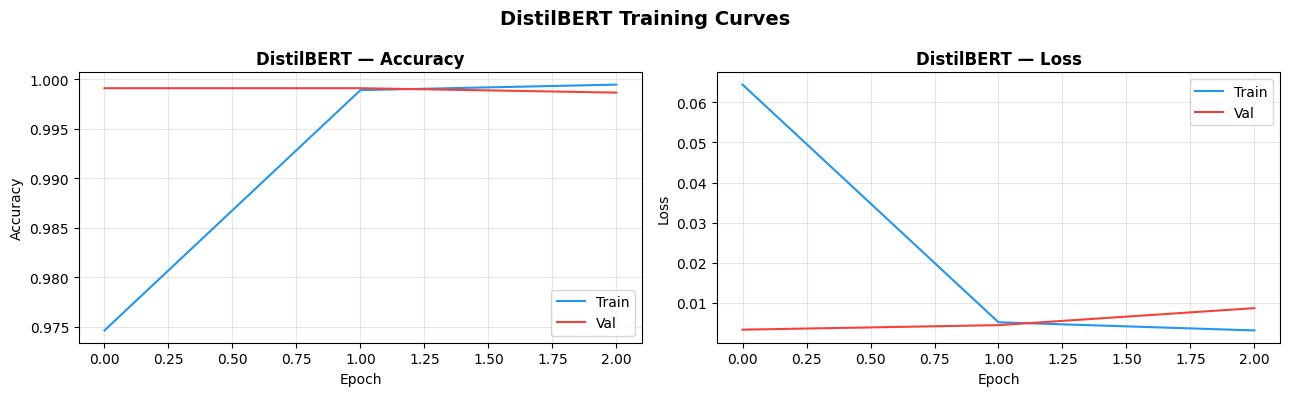

In [75]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))


axes[0].plot(history_distilbert['accuracy'],     label='Train', color='#2196F3')
axes[0].plot(history_distilbert['val_accuracy'], label='Val',   color='#F44336')
axes[0].set_title('DistilBERT — Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_distilbert['loss'],     label='Train', color='#2196F3')
axes[1].plot(history_distilbert['val_loss'], label='Val',   color='#F44336')
axes[1].set_title('DistilBERT — Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('DistilBERT Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distilbert_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluate on Test Set

In [76]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)
import numpy as np

model_distilbert.eval()
all_probs, all_preds, all_labels = [], [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['label']

        logits = model_distilbert(input_ids, attention_mask).squeeze(1)
        probs  = torch.sigmoid(logits).cpu().numpy()
        preds  = (probs >= 0.5).astype(int)

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

y_pred_prob_distilbert = np.array(all_probs)
y_pred_distilbert      = np.array(all_preds)
y_test_np              = np.array(all_labels)

results_distilbert = {
    'Model'     : 'DistilBERT',
    'Accuracy'  : accuracy_score(y_test_np, y_pred_distilbert),
    'Precision' : precision_score(y_test_np, y_pred_distilbert),
    'Recall'    : recall_score(y_test_np, y_pred_distilbert),
    'F1'        : f1_score(y_test_np, y_pred_distilbert),
    'AUC-ROC'   : roc_auc_score(y_test_np, y_pred_prob_distilbert),
    'Train Time': f'{distilbert_train_time:.1f}s'
}

print('=== DistilBERT Test Results ===')
for k, v in results_distilbert.items():
    if isinstance(v, float):
        print(f'  {k:<12} : {v:.4f}')
    else:
        print(f'  {k:<12} : {v}')

print('\n=== Classification Report ===')
print(classification_report(y_test_np, y_pred_distilbert, target_names=['Real', 'Fake']))

=== DistilBERT Test Results ===
  Model        : DistilBERT
  Accuracy     : 0.9987
  Precision    : 0.9991
  Recall       : 0.9983
  F1           : 0.9987
  AUC-ROC      : 1.0000
  Train Time   : 5509.8s

=== Classification Report ===
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      2142
        Fake       1.00      1.00      1.00      2348

    accuracy                           1.00      4490
   macro avg       1.00      1.00      1.00      4490
weighted avg       1.00      1.00      1.00      4490



## Confusion Matrix

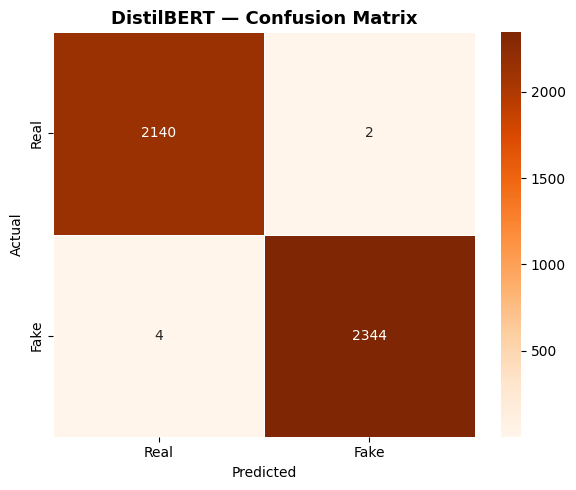

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_distilbert)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Oranges',
    xticklabels=['Real', 'Fake'],
    yticklabels=['Real', 'Fake'],
    linewidths=0.5
)
plt.title('DistilBERT — Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('distilbert_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Final Four-Model Comparisonm

In [78]:
import pandas as pd
import pickle

with open(f'{SAVE_DIR}/results_lstm.pkl', 'rb') as f:
    results_lstm = pickle.load(f)
with open(f'{SAVE_DIR}/results_bilstm.pkl', 'rb') as f:
    results_bilstm = pickle.load(f)
with open(f'{SAVE_DIR}/results_textcnn.pkl', 'rb') as f:
    results_textcnn = pickle.load(f)

comparison_df = pd.DataFrame([
    results_lstm,
    results_bilstm,
    results_textcnn,
    results_distilbert
]).set_index('Model')

print('=== Final Model Comparison — Scenario 1 ===')
print(comparison_df.to_string())

=== Final Model Comparison — Scenario 1 ===
            Accuracy  Precision    Recall        F1   AUC-ROC Train Time
Model                                                                   
LSTM        0.843207   0.812548  0.910136  0.858578  0.877057      71.1s
BiLSTM      0.996214   0.995746  0.997019  0.996382  0.999808     297.1s
TextCNN     0.998218   0.997872  0.998722  0.998297  0.999989      82.0s
DistilBERT  0.998664   0.999147  0.998296  0.998722  0.999994    5509.8s


## Save DistilBERT Results

In [79]:
import pickle

with open(f'{SAVE_DIR}/results_distilbert.pkl', 'wb') as f:
    pickle.dump(results_distilbert, f)

print('Saved: results_distilbert.pkl')
print('\nDistilbert done.')

Saved: results_distilbert.pkl

[06_distilbert.py complete] — next: 07_experiments.py


In [85]:
import pickle

SAVE_DIR = '/content/drive/MyDrive/datasets/deepLearning/FP/models'

with open(f'{SAVE_DIR}/results_lstm.pkl', 'rb') as f:
    r = pickle.load(f)
print(r)

{'Model': 'LSTM', 'Accuracy': 0.8432071269487751, 'Precision': 0.8125475285171103, 'Recall': 0.9101362862010222, 'F1': 0.8585777420650864, 'AUC-ROC': np.float64(0.8770574953433955), 'Train Time': '71.1s'}


In [86]:
import os
import numpy as np
import tensorflow as tf

PROCESSED_DIR = '/content/drive/MyDrive/datasets/deepLearning/FP/processed'
SAVE_DIR      = '/content/drive/MyDrive/datasets/deepLearning/FP/models'

MAX_VOCAB   = 20000
MAX_LENGTH  = 512
EMBED_DIM   = 100
LSTM_UNITS  = 128
DROPOUT     = 0.3
BATCH_SIZE  = 64
EPOCHS      = 10
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print('Config ready.')

Config ready.


In [87]:
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle

train_df = pd.read_csv(f'{PROCESSED_DIR}/train.csv')
val_df   = pd.read_csv(f'{PROCESSED_DIR}/val.csv')
test_df  = pd.read_csv(f'{PROCESSED_DIR}/test.csv')

X_train, y_train = train_df['text'].values, train_df['label'].values
X_val,   y_val   = val_df['text'].values,   val_df['label'].values
X_test,  y_test  = test_df['text'].values,  test_df['label'].values

# Load saved tokenizer
with open(f'{SAVE_DIR}/tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train),
                             maxlen=MAX_LENGTH, padding='post', truncating='post')
X_val_pad   = pad_sequences(tokenizer.texts_to_sequences(X_val),
                             maxlen=MAX_LENGTH, padding='post', truncating='post')
X_test_pad  = pad_sequences(tokenizer.texts_to_sequences(X_test),
                             maxlen=MAX_LENGTH, padding='post', truncating='post')

vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
print(f'Data ready. Vocab size: {vocab_size:,}')

Data ready. Vocab size: 20,000


In [94]:
import numpy as np

GLOVE_PATH = '/content/drive/MyDrive/datasets/deepLearning/FP/glove.6B.100d.txt'

embeddings_index = {}
with open(GLOVE_PATH, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        embeddings_index[values[0]] = np.array(values[1:], dtype='float32')

embedding_matrix = np.zeros((vocab_size, EMBED_DIM))
for word, idx in tokenizer.word_index.items():
    if idx >= MAX_VOCAB:
        continue
    vec = embeddings_index.get(word)
    if vec is not None:
        embedding_matrix[idx] = vec

print(f'GloVe ready. Coverage: {(embedding_matrix.any(axis=1).sum() / vocab_size * 100):.1f}%')

GloVe ready. Coverage: 94.7%


In [95]:
import time
import pickle
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Build
model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM,
              weights=[embedding_matrix], trainable=False),
    LSTM(LSTM_UNITS),
    Dropout(DROPOUT),
    Dense(1, activation='sigmoid')
], name='LSTM_Model')

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=f'{SAVE_DIR}/lstm_best.keras',
                    monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

start = time.time()
model_lstm.fit(X_train_pad, y_train, validation_data=(X_val_pad, y_val),
               epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=callbacks, verbose=1)
lstm_train_time = time.time() - start

# Evaluate
y_prob = model_lstm.predict(X_test_pad, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)

results_lstm = {
    'Model'     : 'LSTM',
    'Accuracy'  : accuracy_score(y_test, y_pred),
    'Precision' : precision_score(y_test, y_pred),
    'Recall'    : recall_score(y_test, y_pred),
    'F1'        : f1_score(y_test, y_pred),
    'AUC-ROC'   : roc_auc_score(y_test, y_prob),
    'Train Time': f'{lstm_train_time:.1f}s'
}

print('\n=== LSTM Results ===')
for k, v in results_lstm.items():
    print(f'  {k:<12} : {v:.4f}' if isinstance(v, float) else f'  {k:<12} : {v}')

# Save
with open(f'{SAVE_DIR}/results_lstm.pkl', 'wb') as f:
    pickle.dump(results_lstm, f)

print('\nSaved: results_lstm.pkl')

Epoch 1/10
561/562 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6188 - loss: 0.6295
Epoch 1: val_loss improved from None to 0.68251, saving model to /content/drive/MyDrive/datasets/deepLearning/FP/models/lstm_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/datasets/deepLearning/FP/models/lstm_best.keras
562/562 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.6120 - loss: 0.6363 - val_accuracy: 0.5394 - val_loss: 0.6825 - learning_rate: 0.0010
Epoch 2/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5574 - loss: 0.6754
Epoch 2: val_loss did not improve from 0.68251
562/562 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.5583 - loss: 0.6768 - val_accuracy: 0.5679 - val_loss: 0.6826 - learning_rate: 0.0010
Epoch 3/10
560/562 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6301 - loss: 0.6234
Epoch 3: val_loss improved from 0.68251 to 0.49155, saving model to /content/drive/MyDrive/datasets/deepLearning/FP/models/lstm_best.keras

Epoch 3: finished saving

# Experiments

## Config

In [96]:
import os
import numpy as np
import tensorflow as tf

PROCESSED_DIR = '/content/drive/MyDrive/datasets/deepLearning/FP/processed'
SAVE_DIR      = '/content/drive/MyDrive/datasets/deepLearning/FP/models'
MERGED_PATH   = '/content/drive/MyDrive/datasets/deepLearning/FP/isot_merged.csv'

# TextCNN hyperparameters — same as 05_textcnn.py for fair comparison
MAX_VOCAB    = 20000
MAX_LENGTH   = 512
EMBED_DIM    = 100
FILTER_SIZES = [2, 3, 4]
NUM_FILTERS  = 128
DROPOUT      = 0.5
BATCH_SIZE   = 64
EPOCHS       = 10
RANDOM_SEED  = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print('Config ready.')

Config ready.


## Helper: Build TextCNN

In [97]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Dense, Dropout, Concatenate
)

def build_textcnn(vocab_size, embedding_matrix, max_length,
                  embed_dim, filter_sizes, num_filters, dropout):
    input_layer     = Input(shape=(max_length,))
    embedding_layer = Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        weights=[embedding_matrix],
        trainable=False
    )(input_layer)

    branches = []
    for fs in filter_sizes:
        conv = Conv1D(filters=num_filters, kernel_size=fs, activation='relu')(embedding_layer)
        pool = GlobalMaxPooling1D()(conv)
        branches.append(pool)

    concat  = Concatenate()(branches)
    drop    = Dropout(dropout)(concat)
    output  = Dense(1, activation='sigmoid')(drop)

    model = Model(inputs=input_layer, outputs=output)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

print('build_textcnn() helper ready.')

build_textcnn() helper ready.


## Helper: Tokenize & Pad

In [98]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

def tokenize_and_pad(X_train, X_val, X_test, max_vocab, max_length):
    tokenizer = Tokenizer(num_words=max_vocab, oov_token='<OOV>')
    tokenizer.fit_on_texts(X_train)

    def encode(texts):
        seqs = tokenizer.texts_to_sequences(texts)
        return pad_sequences(seqs, maxlen=max_length, padding='post', truncating='post')

    return encode(X_train), encode(X_val), encode(X_test), tokenizer

print('tokenize_and_pad() helper ready.')

tokenize_and_pad() helper ready.


## Helper: Load GloVe

In [99]:
import numpy as np

GLOVE_PATH = '/content/drive/MyDrive/datasets/deepLearning/FP/glove.6B.100d.txt'

def load_glove(path):
    index = {}
    with open(path, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            index[values[0]] = np.array(values[1:], dtype='float32')
    print(f'GloVe loaded : {len(index):,} vectors')
    return index

def build_embedding_matrix(tokenizer, glove_index, max_vocab, embed_dim):
    vocab_size = min(max_vocab, len(tokenizer.word_index) + 1)
    matrix     = np.zeros((vocab_size, embed_dim))
    hits       = 0
    for word, idx in tokenizer.word_index.items():
        if idx >= max_vocab:
            continue
        vec = glove_index.get(word)
        if vec is not None:
            matrix[idx] = vec
            hits += 1
    print(f'Embedding coverage : {hits / vocab_size * 100:.1f}%')
    return matrix, vocab_size

glove_index = load_glove(GLOVE_PATH)
print('Helpers ready.')

GloVe loaded : 400,000 vectors
Helpers ready.


## Helper: Train & Evaluate

In [100]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time

def train_and_evaluate(model, X_train_pad, y_train, X_val_pad, y_val,
                       X_test_pad, y_test, batch_size, epochs, label):
    callbacks = [EarlyStopping(monitor='val_loss', patience=3,
                               restore_best_weights=True, verbose=0)]
    start = time.time()
    model.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=0   # silent — we only care about final metrics here
    )
    elapsed = time.time() - start

    y_prob = model.predict(X_test_pad, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    results = {
        'Variant'   : label,
        'Accuracy'  : accuracy_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred),
        'Recall'    : recall_score(y_test, y_pred),
        'F1'        : f1_score(y_test, y_pred),
        'AUC-ROC'   : roc_auc_score(y_test, y_prob),
        'Train Time': f'{elapsed:.1f}s'
    }

    print(f'  [{label}] Acc={results["Accuracy"]:.4f}  '
          f'F1={results["F1"]:.4f}  AUC={results["AUC-ROC"]:.4f}  '
          f'Time={results["Train Time"]}')
    return results

print('train_and_evaluate() helper ready.')

train_and_evaluate() helper ready.


## Scenario 1: Model Comparison (load saved results)

In [101]:
import pickle
import pandas as pd

with open(f'{SAVE_DIR}/results_lstm.pkl',       'rb') as f: r_lstm       = pickle.load(f)
with open(f'{SAVE_DIR}/results_bilstm.pkl',     'rb') as f: r_bilstm     = pickle.load(f)
with open(f'{SAVE_DIR}/results_textcnn.pkl',    'rb') as f: r_textcnn    = pickle.load(f)
with open(f'{SAVE_DIR}/results_distilbert.pkl', 'rb') as f: r_distilbert = pickle.load(f)

# Rename 'Model' key to 'Variant' for consistent column naming
for r in [r_lstm, r_bilstm, r_textcnn, r_distilbert]:
    r['Variant'] = r.pop('Model')

scenario1_df = pd.DataFrame([r_lstm, r_bilstm, r_textcnn, r_distilbert])
scenario1_df = scenario1_df.set_index('Variant')

print('=== SCENARIO 1: Model Comparison ===')
print(scenario1_df.to_string())

=== SCENARIO 1: Model Comparison ===
            Accuracy  Precision    Recall        F1   AUC-ROC Train Time
Variant                                                                 
LSTM        0.989978   0.988545  0.992334  0.990436  0.999089     178.3s
BiLSTM      0.996214   0.995746  0.997019  0.996382  0.999808     297.1s
TextCNN     0.998218   0.997872  0.998722  0.998297  0.999989      82.0s
DistilBERT  0.998664   0.999147  0.998296  0.998722  0.999994    5509.8s


##  Scenario 1: Visualization

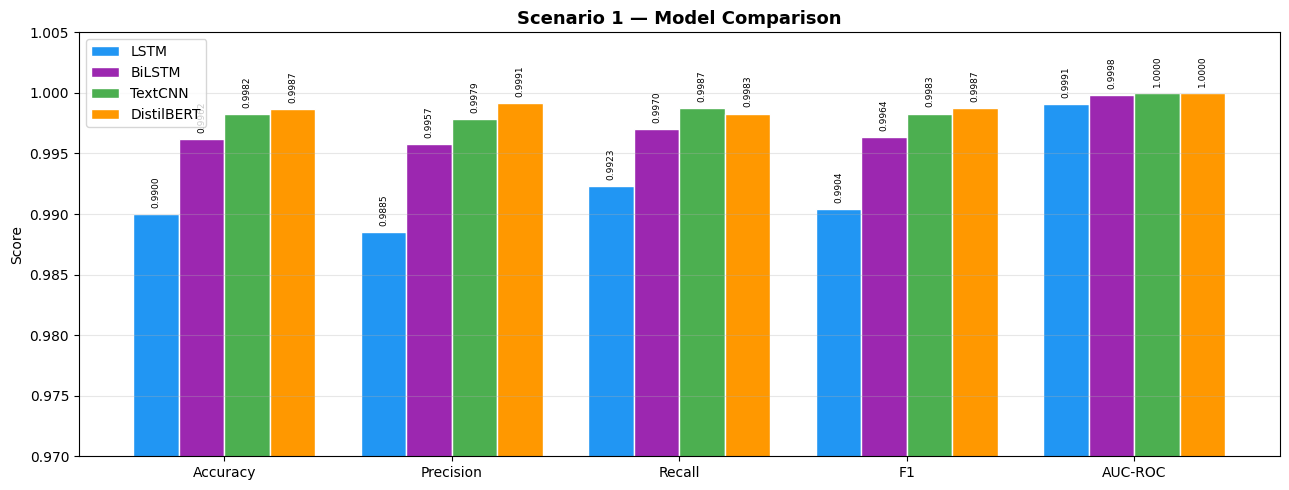

In [102]:
import matplotlib.pyplot as plt
import pandas as pd

metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
models  = scenario1_df.index.tolist()
colors  = ['#2196F3', '#9C27B0', '#4CAF50', '#FF9800']

x      = range(len(metrics))
width  = 0.2
fig, ax = plt.subplots(figsize=(13, 5))

for i, (model, color) in enumerate(zip(models, colors)):
    values = [scenario1_df.loc[model, m] for m in metrics]
    bars   = ax.bar([xi + i * width for xi in x], values,
                    width=width, label=model, color=color, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.0005,
                f'{bar.get_height():.4f}',
                ha='center', va='bottom', fontsize=6.5, rotation=90)

ax.set_xticks([xi + width * 1.5 for xi in x])
ax.set_xticklabels(metrics)
ax.set_ylim(0.97, 1.005)
ax.set_ylabel('Score')
ax.set_title('Scenario 1 — Model Comparison', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('scenario1_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

##  Scenario 2: Prepare Input Variants

In [103]:
import pandas as pd
import re
import numpy as np

# Load merged raw dataset
df_merged = pd.read_csv(MERGED_PATH)

# Reuse clean_text from preprocessing
CONTRACTIONS = {
    "n't": " not", "'re": " are", "'s": " is", "'d": " would",
    "'ll": " will", "'ve": " have", "'m": " am"
}

def expand_contractions(text):
    text = text.lower()
    for k, v in CONTRACTIONS.items():
        text = text.replace(k, v)
    return text

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"'s\b", " is", text)
    text = re.sub(r"n't\b", " not", text)
    text = re.sub(r"'re\b", " are", text)
    text = re.sub(r"'ve\b", " have", text)
    text = re.sub(r"'ll\b", " will", text)
    text = re.sub(r"'d\b",  " would", text)
    text = re.sub(r"'m\b",  " am", text)
    text = expand_contractions(text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\(reuters\)', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\b\w\b', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Three input variants
df_merged['title_only']    = df_merged['title'].fillna('').apply(clean_text)
df_merged['body_only']     = df_merged['text'].fillna('').apply(clean_text)
df_merged['title_and_body']= df_merged['title'].fillna('') + ' [SEP] ' + df_merged['text'].fillna('')
df_merged['title_and_body']= df_merged['title_and_body'].apply(clean_text)

print('Input variants created:')
print(f'  title_only     sample: {df_merged["title_only"].iloc[0][:80]}')
print(f'  body_only      sample: {df_merged["body_only"].iloc[0][:80]}')
print(f'  title_and_body sample: {df_merged["title_and_body"].iloc[0][:80]}')

Input variants created:
  title_only     sample: as us budget fight looms republicans flip their fiscal script
  body_only      sample: washington the head of conservative republican faction in the us congress who vo
  title_and_body sample: as us budget fight looms republicans flip their fiscal script sep washington the


##  Scenario 2: Run Experiments

In [104]:
from sklearn.model_selection import train_test_split

scenario2_results = []
variants = {
    'Title Only'    : df_merged['title_only'].values,
    'Body Only'     : df_merged['body_only'].values,
    'Title + Body'  : df_merged['title_and_body'].values
}

y_all = df_merged['label'].values

for variant_name, X_all in variants.items():
    print(f'\nRunning: {variant_name}')

    # Split
    X_temp, X_test, y_temp, y_test = train_test_split(
        X_all, y_all, test_size=0.10, stratify=y_all, random_state=RANDOM_SEED)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.111, stratify=y_temp, random_state=RANDOM_SEED)

    # Tokenize
    X_train_pad, X_val_pad, X_test_pad, tok = tokenize_and_pad(
        X_train, X_val, X_test, MAX_VOCAB, MAX_LENGTH)

    # Embedding
    emb_matrix, vocab_size = build_embedding_matrix(tok, glove_index, MAX_VOCAB, EMBED_DIM)

    # Build & train
    model = build_textcnn(vocab_size, emb_matrix, MAX_LENGTH,
                          EMBED_DIM, FILTER_SIZES, NUM_FILTERS, DROPOUT)
    result = train_and_evaluate(model, X_train_pad, y_train,
                                X_val_pad, y_val, X_test_pad, y_test,
                                BATCH_SIZE, EPOCHS, variant_name)
    scenario2_results.append(result)

scenario2_df = pd.DataFrame(scenario2_results).set_index('Variant')
print('\n=== SCENARIO 2: Input Feature Ablation ===')
print(scenario2_df.to_string())


Running: Title Only
Embedding coverage : 81.5%
  [Title Only] Acc=0.9592  F1=0.9609  AUC=0.9938  Time=75.8s

Running: Body Only
Embedding coverage : 94.7%
  [Body Only] Acc=0.9967  F1=0.9968  AUC=0.9998  Time=79.6s

Running: Title + Body
Embedding coverage : 94.7%
  [Title + Body] Acc=0.9982  F1=0.9983  AUC=1.0000  Time=79.8s

=== SCENARIO 2: Input Feature Ablation ===
              Accuracy  Precision    Recall        F1   AUC-ROC Train Time
Variant                                                                   
Title Only    0.959243   0.963597  0.958262  0.960922  0.993831      75.8s
Body Only     0.996659   0.997017  0.996593  0.996805  0.999785      79.6s
Title + Body  0.998218   0.997872  0.998722  0.998297  0.999992      79.8s


## Scenario 2: Visualization

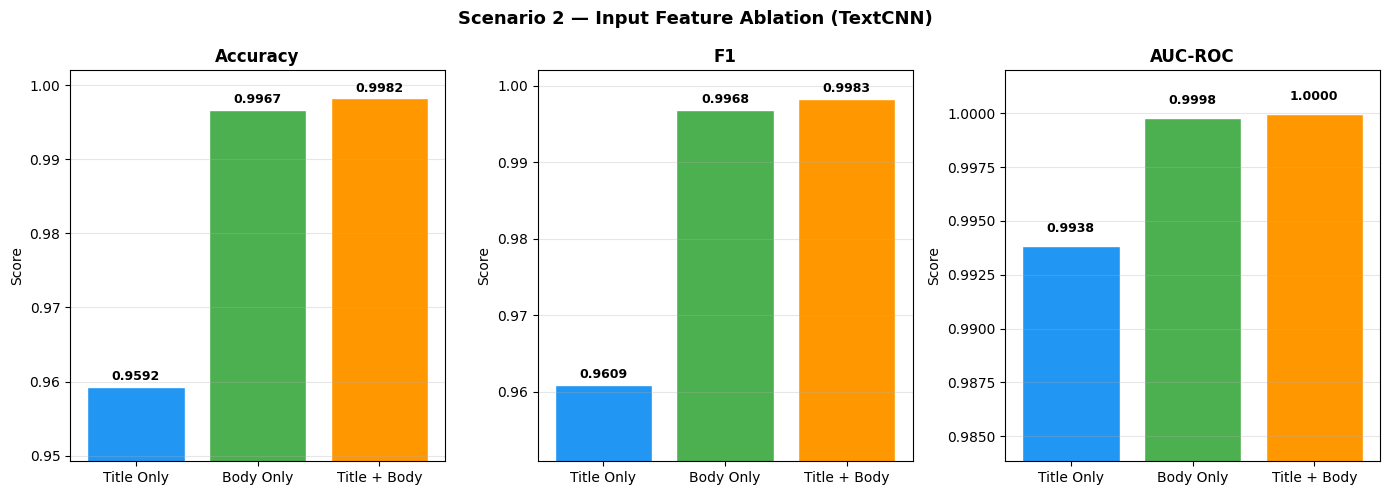

In [105]:
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'F1', 'AUC-ROC']
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800']

for ax, metric in zip(axes, metrics):
    values  = scenario2_df[metric].values
    labels  = scenario2_df.index.tolist()
    bars    = ax.bar(labels, values, color=colors, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(min(values) - 0.01, 1.002)
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.0005,
                f'{bar.get_height():.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Scenario 2 — Input Feature Ablation (TextCNN)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scenario2_input_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

## Scenario 3: Prepare Preprocessing Variants

In [107]:
import re

# Variant A: No preprocessing — raw combined text, lowercase only
df_merged['no_clean'] = (
    df_merged['title'].fillna('') + ' ' + df_merged['text'].fillna('')
).apply(lambda x: x.lower().strip())

# Variant B: Basic cleaning — remove URLs, HTML, punctuation only
def basic_clean(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # remove URLs
    text = re.sub(r'<.*?>', '', text)                    # remove HTML
    text = re.sub(r'[^a-z\s]', '', text)                # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_merged['basic_clean'] = (
    df_merged['title'].fillna('') + ' ' + df_merged['text'].fillna('')
).apply(basic_clean)

# Variant C: Full pipeline — same as 02_preprocessing.py
df_merged['full_clean'] = df_merged['title_and_body']  # already computed in Cell 8

print('Preprocessing variants ready:')
print(f'  no_clean    : {df_merged["no_clean"].iloc[0][:80]}')
print(f'  basic_clean : {df_merged["basic_clean"].iloc[0][:80]}')
print(f'  full_clean  : {df_merged["full_clean"].iloc[0][:80]}')

Preprocessing variants ready:
  no_clean    : as u.s. budget fight looms, republicans flip their fiscal script washington (reu
  basic_clean : as us budget fight looms republicans flip their fiscal script washington reuters
  full_clean  : as us budget fight looms republicans flip their fiscal script sep washington the


## Scenario 3: Run Experiments

In [108]:
scenario3_results = []
variants_s3 = {
    'No Cleaning'    : df_merged['no_clean'].values,
    'Basic Cleaning' : df_merged['basic_clean'].values,
    'Full Pipeline'  : df_merged['full_clean'].values
}

for variant_name, X_all in variants_s3.items():
    print(f'\nRunning: {variant_name}')

    X_temp, X_test, y_temp, y_test = train_test_split(
        X_all, y_all, test_size=0.10, stratify=y_all, random_state=RANDOM_SEED)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.111, stratify=y_temp, random_state=RANDOM_SEED)

    X_train_pad, X_val_pad, X_test_pad, tok = tokenize_and_pad(
        X_train, X_val, X_test, MAX_VOCAB, MAX_LENGTH)

    emb_matrix, vocab_size = build_embedding_matrix(tok, glove_index, MAX_VOCAB, EMBED_DIM)

    model = build_textcnn(vocab_size, emb_matrix, MAX_LENGTH,
                          EMBED_DIM, FILTER_SIZES, NUM_FILTERS, DROPOUT)
    result = train_and_evaluate(model, X_train_pad, y_train,
                                X_val_pad, y_val, X_test_pad, y_test,
                                BATCH_SIZE, EPOCHS, variant_name)
    scenario3_results.append(result)

scenario3_df = pd.DataFrame(scenario3_results).set_index('Variant')
print('\n=== SCENARIO 3: Preprocessing Impact ===')
print(scenario3_df.to_string())


Running: No Cleaning
Embedding coverage : 95.2%
  [No Cleaning] Acc=0.9993  F1=0.9994  AUC=1.0000  Time=82.5s

Running: Basic Cleaning
Embedding coverage : 94.7%
  [Basic Cleaning] Acc=0.9984  F1=0.9985  AUC=1.0000  Time=81.1s

Running: Full Pipeline
Embedding coverage : 94.7%
  [Full Pipeline] Acc=0.9980  F1=0.9981  AUC=1.0000  Time=81.5s

=== SCENARIO 3: Preprocessing Impact ===
                Accuracy  Precision    Recall        F1   AUC-ROC Train Time
Variant                                                                     
No Cleaning     0.999332   1.000000  0.998722  0.999361  0.999999      82.5s
Basic Cleaning  0.998441   0.999573  0.997445  0.998508  0.999997      81.1s
Full Pipeline   0.997996   0.998721  0.997445  0.998082  0.999984      81.5s


## Scenario 3: Visualization

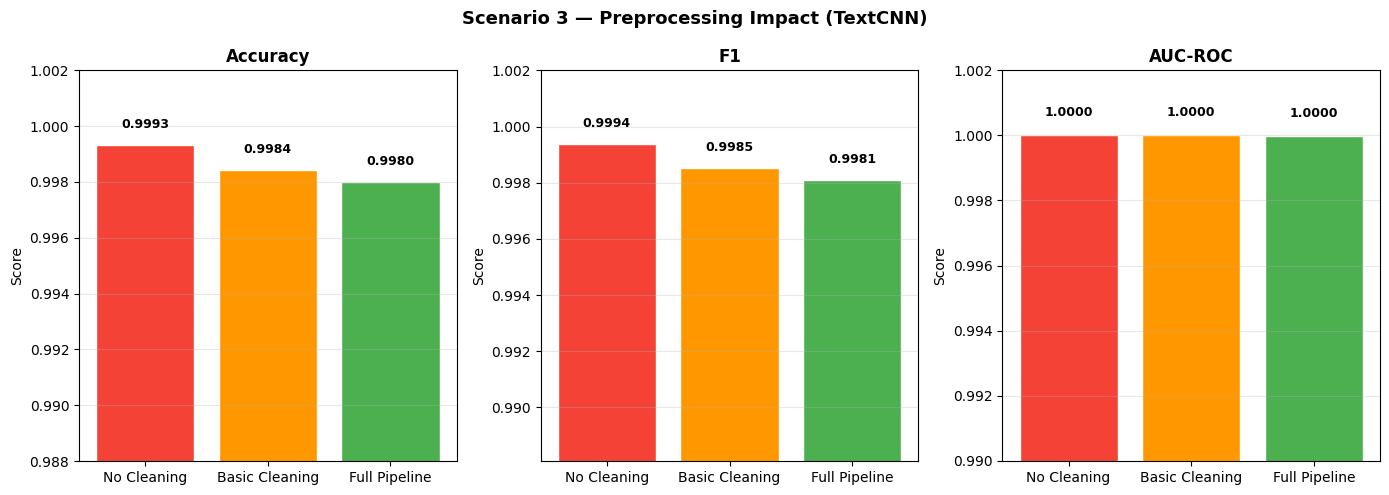

In [109]:
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'F1', 'AUC-ROC']
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ['#F44336', '#FF9800', '#4CAF50']

for ax, metric in zip(axes, metrics):
    values = scenario3_df[metric].values
    labels = scenario3_df.index.tolist()
    bars   = ax.bar(labels, values, color=colors, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(min(values) - 0.01, 1.002)
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.0005,
                f'{bar.get_height():.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Scenario 3 — Preprocessing Impact (TextCNN)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scenario3_preprocessing_impact.png', dpi=150, bbox_inches='tight')
plt.show()

##  Final Summary: All Scenarios

In [110]:
import pandas as pd

print('=' * 60)
print('SCENARIO 1 — Model Comparison')
print('=' * 60)
print(scenario1_df[['Accuracy', 'F1', 'AUC-ROC', 'Train Time']].to_string())

print('\n' + '=' * 60)
print('SCENARIO 2 — Input Feature Ablation (TextCNN)')
print('=' * 60)
print(scenario2_df[['Accuracy', 'F1', 'AUC-ROC', 'Train Time']].to_string())

print('\n' + '=' * 60)
print('SCENARIO 3 — Preprocessing Impact (TextCNN)')
print('=' * 60)
print(scenario3_df[['Accuracy', 'F1', 'AUC-ROC', 'Train Time']].to_string())

SCENARIO 1 — Model Comparison
            Accuracy        F1   AUC-ROC Train Time
Variant                                            
LSTM        0.989978  0.990436  0.999089     178.3s
BiLSTM      0.996214  0.996382  0.999808     297.1s
TextCNN     0.998218  0.998297  0.999989      82.0s
DistilBERT  0.998664  0.998722  0.999994    5509.8s

SCENARIO 2 — Input Feature Ablation (TextCNN)
              Accuracy        F1   AUC-ROC Train Time
Variant                                              
Title Only    0.959243  0.960922  0.993831      75.8s
Body Only     0.996659  0.996805  0.999785      79.6s
Title + Body  0.998218  0.998297  0.999992      79.8s

SCENARIO 3 — Preprocessing Impact (TextCNN)
                Accuracy        F1   AUC-ROC Train Time
Variant                                                
No Cleaning     0.999332  0.999361  0.999999      82.5s
Basic Cleaning  0.998441  0.998508  0.999997      81.1s
Full Pipeline   0.997996  0.998082  0.999984      81.5s


##  Save All Results

In [113]:
import pickle

with open(f'{SAVE_DIR}/scenario1_results.pkl', 'wb') as f:
    pickle.dump(scenario1_df, f)
with open(f'{SAVE_DIR}/scenario2_results.pkl', 'wb') as f:
    pickle.dump(scenario2_df, f)
with open(f'{SAVE_DIR}/scenario3_results.pkl', 'wb') as f:
    pickle.dump(scenario3_df, f)

print('All scenario results saved.')
print('\n Experiments Completed')
print('Next: wait for DistilBERT to finish, then run Cell 6 to load its results.')

All scenario results saved.

 Experiments Completed
Next: wait for DistilBERT to finish, then run Cell 6 to load its results.


# Evaluation

## Config

In [114]:
import os

SAVE_DIR = '/content/drive/MyDrive/datasets/deepLearning/FP/models'

MODEL_NAMES = ['LSTM', 'BiLSTM', 'TextCNN', 'DistilBERT']
COLORS      = {
    'LSTM'      : '#2196F3',
    'BiLSTM'    : '#9C27B0',
    'TextCNN'   : '#4CAF50',
    'DistilBERT': '#FF9800'
}

print('Config ready.')

Config ready.


## Load All Results

In [115]:
import pickle
import pandas as pd

with open(f'{SAVE_DIR}/results_lstm.pkl',       'rb') as f: r_lstm       = pickle.load(f)
with open(f'{SAVE_DIR}/results_bilstm.pkl',     'rb') as f: r_bilstm     = pickle.load(f)
with open(f'{SAVE_DIR}/results_textcnn.pkl',    'rb') as f: r_textcnn    = pickle.load(f)
with open(f'{SAVE_DIR}/results_distilbert.pkl', 'rb') as f: r_distilbert = pickle.load(f)

# Normalize key name
for r in [r_lstm, r_bilstm, r_textcnn, r_distilbert]:
    if 'Model' in r:
        r['Variant'] = r.pop('Model')

all_results = [r_lstm, r_bilstm, r_textcnn, r_distilbert]
results_df  = pd.DataFrame(all_results).set_index('Variant')

print('=== All Model Results ===')
print(results_df.to_string())

=== All Model Results ===
            Accuracy  Precision    Recall        F1   AUC-ROC Train Time
Variant                                                                 
LSTM        0.989978   0.988545  0.992334  0.990436  0.999089     178.3s
BiLSTM      0.996214   0.995746  0.997019  0.996382  0.999808     297.1s
TextCNN     0.998218   0.997872  0.998722  0.998297  0.999989      82.0s
DistilBERT  0.998664   0.999147  0.998296  0.998722  0.999994    5509.8s


## Load Test Sets & Predictions

In [116]:
import pandas as pd
import numpy as np
import pickle

PROCESSED_DIR = '/content/drive/MyDrive/datasets/deepLearning/FP/processed'

test_df = pd.read_csv(f'{PROCESSED_DIR}/test.csv')
y_test  = test_df['label'].values
X_test  = test_df['text'].values

print(f'Test samples : {len(y_test):,}')
print(f'Fake         : {y_test.sum():,}')
print(f'Real         : {(y_test == 0).sum():,}')

Test samples : 4,490
Fake         : 2,348
Real         : 2,142


## Regenerate Predictions (LSTM, BiLSTM, TextCNN)

In [117]:
import tensorflow as tf
import pickle
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB  = 20000
MAX_LENGTH = 512

# Load tokenizer
with open(f'{SAVE_DIR}/tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

# Pad test sequences
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LENGTH,
                            padding='post', truncating='post')

# Load each model and predict
lstm_model    = tf.keras.models.load_model(f'{SAVE_DIR}/lstm_best.keras')
bilstm_model  = tf.keras.models.load_model(f'{SAVE_DIR}/bilstm_best.keras')
textcnn_model = tf.keras.models.load_model(f'{SAVE_DIR}/textcnn_best.keras')

prob_lstm    = lstm_model.predict(X_test_pad,   verbose=0).flatten()
prob_bilstm  = bilstm_model.predict(X_test_pad, verbose=0).flatten()
prob_textcnn = textcnn_model.predict(X_test_pad,verbose=0).flatten()

pred_lstm    = (prob_lstm    >= 0.5).astype(int)
pred_bilstm  = (prob_bilstm  >= 0.5).astype(int)
pred_textcnn = (prob_textcnn >= 0.5).astype(int)

print('Predictions ready for LSTM, BiLSTM, TextCNN.')

Predictions ready for LSTM, BiLSTM, TextCNN.


## Regenerate Predictions (DistilBERT)

In [118]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
import numpy as np

MODEL_NAME = 'distilbert-base-uncased'
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 16

# Rebuild model architecture
class DistilBERTClassifier(nn.Module):
    def __init__(self, model_name, dropout=0.1):
        super().__init__()
        self.distilbert = AutoModel.from_pretrained(model_name)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(768, 1)

    def forward(self, input_ids, attention_mask):
        outputs    = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        return self.classifier(self.dropout(cls_output))

distilbert_model = DistilBERTClassifier(MODEL_NAME).to(DEVICE)
distilbert_model.load_state_dict(
    torch.load(f'{SAVE_DIR}/distilbert_best.pt', map_location=DEVICE)
)
distilbert_model.eval()

# Tokenize test set
bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoding       = bert_tokenizer(
    list(X_test), max_length=512, padding='max_length',
    truncation=True, return_tensors='np'
)

# Predict in batches
all_probs = []
input_ids_all = encoding['input_ids']
mask_all      = encoding['attention_mask']

for i in range(0, len(input_ids_all), BATCH_SIZE):
    ids  = torch.tensor(input_ids_all[i:i+BATCH_SIZE], dtype=torch.long).to(DEVICE)
    mask = torch.tensor(mask_all[i:i+BATCH_SIZE],      dtype=torch.long).to(DEVICE)
    with torch.no_grad():
        logits = distilbert_model(ids, mask).squeeze(1)
        probs  = torch.sigmoid(logits).cpu().numpy()
    all_probs.extend(probs)

prob_distilbert = np.array(all_probs)
pred_distilbert = (prob_distilbert >= 0.5).astype(int)

print(f'DistilBERT predictions ready. Samples: {len(prob_distilbert)}')

DistilBERT predictions ready. Samples: 4490


## Confusion Matrices (2×2 grid)

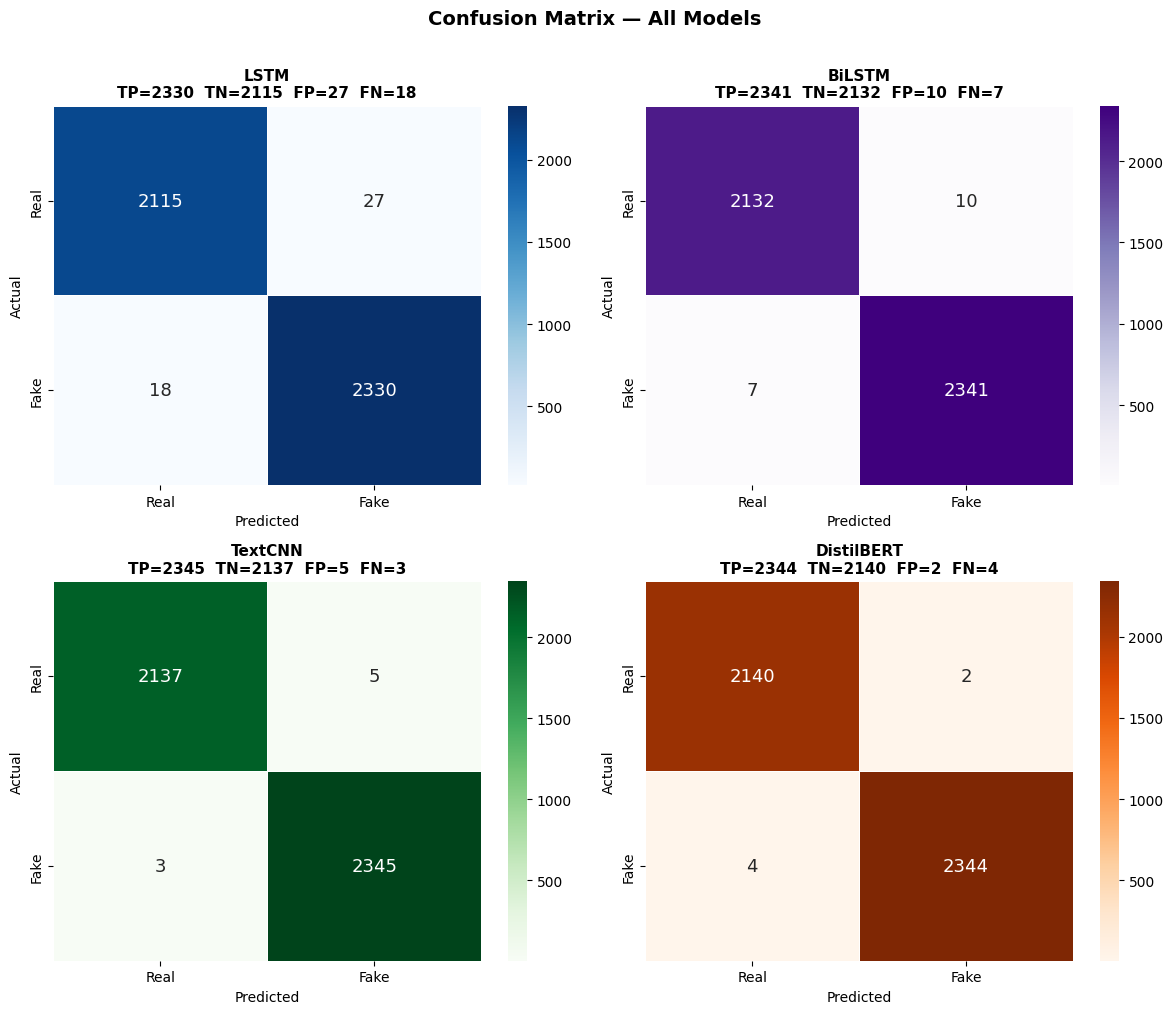

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes      = axes.flatten()

preds = [pred_lstm, pred_bilstm, pred_textcnn, pred_distilbert]
cmaps = ['Blues', 'Purples', 'Greens', 'Oranges']

for ax, model_name, pred, cmap in zip(axes, MODEL_NAMES, preds, cmaps):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap,
        xticklabels=['Real', 'Fake'],
        yticklabels=['Real', 'Fake'],
        linewidths=0.5, ax=ax,
        annot_kws={'size': 13}
    )
    # Add TP TN FP FN labels
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{model_name}\nTP={tp}  TN={tn}  FP={fp}  FN={fn}',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrix — All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## ROC Curves (all models on one plot)

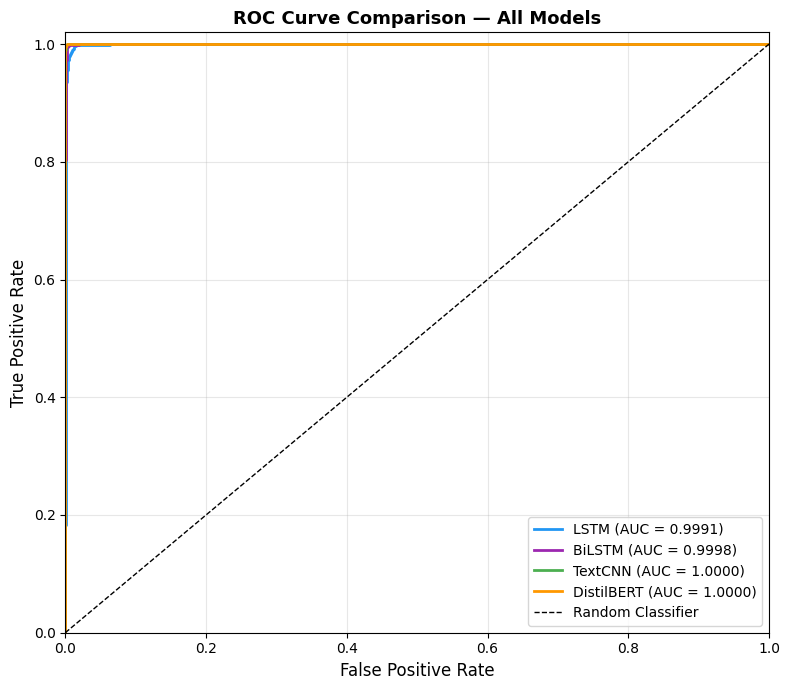

In [120]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 7))

probs_all = [prob_lstm, prob_bilstm, prob_textcnn, prob_distilbert]

for model_name, prob in zip(MODEL_NAMES, probs_all):
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr,
            label=f'{model_name} (AUC = {roc_auc:.4f})',
            color=COLORS[model_name],
            linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

##  Metrics Bar Chart (grouped)

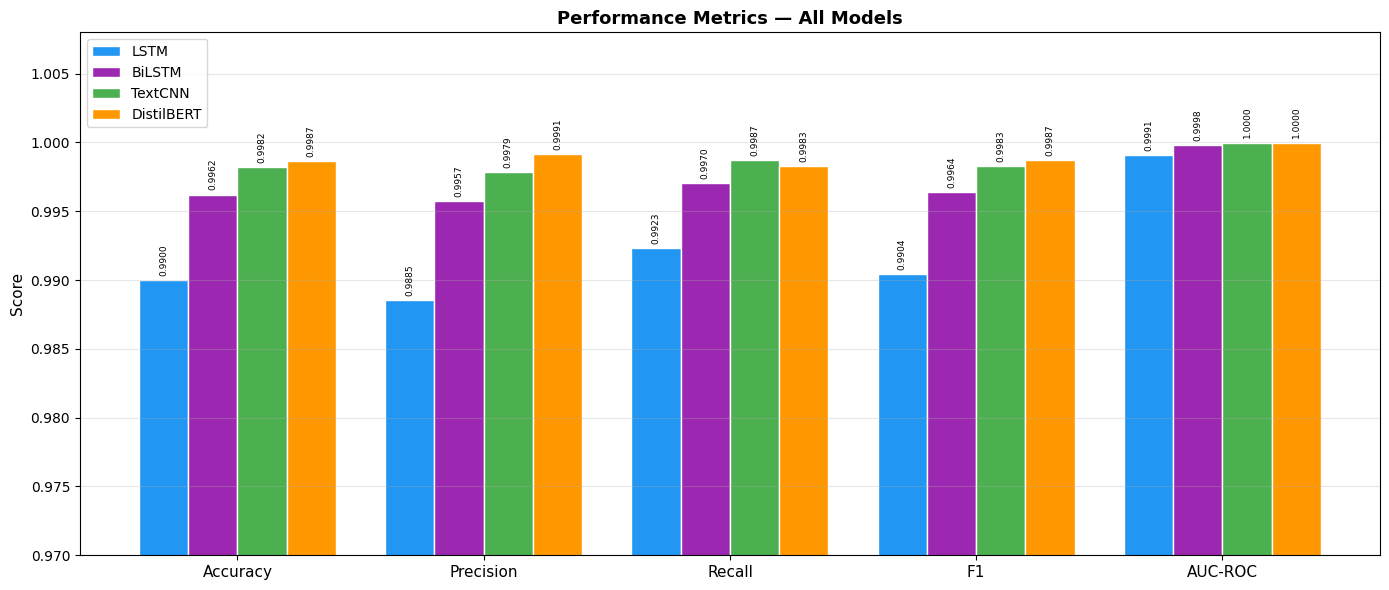

In [121]:
import matplotlib.pyplot as plt
import numpy as np

metrics      = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
x            = np.arange(len(metrics))
width        = 0.2

fig, ax = plt.subplots(figsize=(14, 6))

for i, model_name in enumerate(MODEL_NAMES):
    values = [results_df.loc[model_name, m] for m in metrics]
    bars   = ax.bar(x + i * width, values, width,
                    label=model_name,
                    color=COLORS[model_name],
                    edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.0003,
                f'{bar.get_height():.4f}',
                ha='center', va='bottom',
                fontsize=6.5, rotation=90)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.97, 1.008)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Performance Metrics — All Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Training Time Comparison

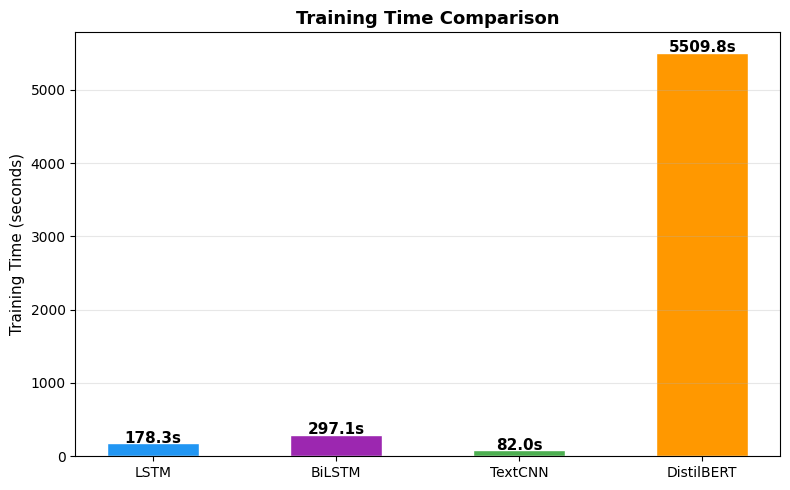

In [122]:
import matplotlib.pyplot as plt

# Parse train times from results
time_values = []
for r in all_results:
    t = float(r['Train Time'].replace('s', ''))
    time_values.append(t)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(MODEL_NAMES, time_values,
              color=[COLORS[m] for m in MODEL_NAMES],
              edgecolor='white', width=0.5)

for bar, val in zip(bars, time_values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            f'{val:.1f}s',
            ha='center', fontweight='bold', fontsize=11)

ax.set_ylabel('Training Time (seconds)', fontsize=11)
ax.set_title('Training Time Comparison', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('training_time_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Final Report-Ready Table

In [123]:
import pandas as pd

# Clean version of results table for copy-pasting into report
report_df = results_df[['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC', 'Train Time']].copy()

# Format floats to 4 decimal places
for col in ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']:
    report_df[col] = report_df[col].apply(lambda x: f'{x:.4f}')

# Highlight best per column
print('=== FINAL RESULTS TABLE (Chapter 3) ===')
print(report_df.to_string())

print('\n=== BEST MODEL PER METRIC ===')
numeric_df = results_df[['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']]
for col in numeric_df.columns:
    best_model = numeric_df[col].idxmax()
    best_val   = numeric_df[col].max()
    print(f'  {col:<12} → {best_model:<12} ({best_val:.4f})')

=== FINAL RESULTS TABLE (Chapter 3) ===
           Accuracy Precision  Recall      F1 AUC-ROC Train Time
Variant                                                         
LSTM         0.9900    0.9885  0.9923  0.9904  0.9991     178.3s
BiLSTM       0.9962    0.9957  0.9970  0.9964  0.9998     297.1s
TextCNN      0.9982    0.9979  0.9987  0.9983  1.0000      82.0s
DistilBERT   0.9987    0.9991  0.9983  0.9987  1.0000    5509.8s

=== BEST MODEL PER METRIC ===
  Accuracy     → DistilBERT   (0.9987)
  Precision    → DistilBERT   (0.9991)
  Recall       → TextCNN      (0.9987)
  F1           → DistilBERT   (0.9987)
  AUC-ROC      → DistilBERT   (1.0000)


## Error Analysis: What did each model get wrong?

In [124]:
import pandas as pd

error_summary = []
preds_all = {
    'LSTM'      : pred_lstm,
    'BiLSTM'    : pred_bilstm,
    'TextCNN'   : pred_textcnn,
    'DistilBERT': pred_distilbert
}

for model_name, pred in preds_all.items():
    errors     = (pred != y_test)
    fp         = ((pred == 1) & (y_test == 0)).sum()  # Real → predicted Fake
    fn         = ((pred == 0) & (y_test == 1)).sum()  # Fake → predicted Real
    error_summary.append({
        'Model'          : model_name,
        'Total Errors'   : errors.sum(),
        'False Positives': fp,   # Real classified as Fake
        'False Negatives': fn,   # Fake classified as Real
        'Error Rate'     : f'{errors.mean()*100:.2f}%'
    })

error_df = pd.DataFrame(error_summary).set_index('Model')
print('=== ERROR ANALYSIS ===')
print(error_df.to_string())
print('\nNote:')
print('  False Positive = Real news wrongly flagged as Fake (more dangerous)')
print('  False Negative = Fake news missed, classified as Real')

=== ERROR ANALYSIS ===
            Total Errors  False Positives  False Negatives Error Rate
Model                                                                
LSTM                  45               27               18      1.00%
BiLSTM                17               10                7      0.38%
TextCNN                8                5                3      0.18%
DistilBERT             6                2                4      0.13%

Note:
  False Positive = Real news wrongly flagged as Fake (more dangerous)
  False Negative = Fake news missed, classified as Real
